In [2]:
import numpy as np
import pandas as pd
import GEOparse

from scipy.stats import ttest_ind
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.multitest import multipletests
from sklearn.feature_selection import SelectKBest, f_classif

In [3]:
import logging

logging.getLogger("GEOparse").setLevel(logging.ERROR)

In [4]:
gse = GEOparse.get_GEO(
    filepath="../data/raw/GSE18123_family.soft"
)

c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (0: SPOT_ID) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


## 1. Dataset Overview

The GSE18123 dataset contains 285 samples measured across two microarray platforms: GPL570 and GPL6244.

For this study, we focus on GPL6244 to maintain a consistent platform for downstream transcriptomic analysis.

In [5]:
print("Number of samples:", len(gse.gsms))
print("Number of platforms:", len(gse.gpls))

Number of samples: 285
Number of platforms: 2


In [6]:
print(gse.gpls.keys())

dict_keys(['GPL570', 'GPL6244'])


In [7]:
# Inspect the number of samples for each platform

platform_counts = {}

for gsm_id, gsm in gse.gsms.items():
    platform = gsm.metadata["platform_id"][0]
    platform_counts[platform] = platform_counts.get(platform, 0) + 1

platform_counts

{'GPL570': 99, 'GPL6244': 186}

In [8]:
# Select samples measured on GPL6244

GPL6244_SAMPLES = [
    gsm_id
    for gsm_id, gsm in gse.gsms.items()
    if gsm.metadata["platform_id"][0] == "GPL6244"
]

print("Number of GPL6244 samples:", len(GPL6244_SAMPLES))
print("First 10 samples:", GPL6244_SAMPLES[:10])

Number of GPL6244 samples: 186
First 10 samples: ['GSM650655', 'GSM650656', 'GSM650657', 'GSM650658', 'GSM650659', 'GSM650660', 'GSM650661', 'GSM650662', 'GSM650663', 'GSM650664']


In [9]:
# Inspect metadata of the first GPL6244 sample

sample_id = GPL6244_SAMPLES[0]

gse.gsms[sample_id].metadata

{'title': ['AC02-1253-01'],
 'geo_accession': ['GSM650655'],
 'status': ['Public on Sep 01 2012'],
 'submission_date': ['Jan 05 2011'],
 'last_update_date': ['Sep 01 2012'],
 'type': ['RNA'],
 'channel_count': ['1'],
 'source_name_ch1': ['Blood'],
 'organism_ch1': ['Homo sapiens'],
 'taxid_ch1': ['9606'],
 'characteristics_ch1': ["diagnosis: ASPERGER'S DISORDER",
  'gender: male',
  'age at blood drawing (months): 156',
  'race: Caucasian',
  'ethnicity: Non-Hispanic',
  'hours (minutes since last caloric intake): : 3:25',
  'chronic diseases: -',
  'allergies: -',
  'developmental/speech disorder: -',
  'neurological disorder: -',
  'psychiatric disorder: -',
  'gastrointestinal disorder: -',
  'autoimmune disorder: -',
  'genetic testing: -',
  'birth defects: -',
  'ct: -',
  'mri: -',
  'medications/vitamin names: ibuprofen, excedrine, multivitamin',
  'cerebral palsy: -',
  'seizure: -',
  'other diseases: -'],
 'molecule_ch1': ['total RNA'],
 'extract_protocol_ch1': ["Trizol extr

## 2. Sample Metadata

Sample-level metadata were extracted from the GEO annotations for the 186 samples measured on GPL6244.

The metadata include diagnostic status, sex, age, and other available clinical characteristics.

In [10]:
import pandas as pd
import re

metadata_rows = []

for sample_id in GPL6244_SAMPLES:
    gsm = gse.gsms[sample_id]
    characteristics = gsm.metadata["characteristics_ch1"]

    row = {
        "sample_id": sample_id,
        "platform": gsm.metadata["platform_id"][0],
        "source": gsm.metadata["source_name_ch1"][0],
    }

    for item in characteristics:
        key, value = item.split(":", 1)
        row[key.strip()] = value.strip()

    metadata_rows.append(row)

metadata = pd.DataFrame(metadata_rows)

print("Metadata shape:", metadata.shape)
metadata.head()

Metadata shape: (186, 24)


,sample_id,platform,source,diagnosis,gender,age at blood drawing (months),race,ethnicity,hours (minutes since last caloric intake),chronic diseases,...,gastrointestinal disorder,autoimmune disorder,genetic testing,birth defects,ct,mri,medications/vitamin names,cerebral palsy,seizure,other diseases
0,GSM650655,GPL6244,Blood,ASPERGER'S DISORDER,male,156,Caucasian,Non-Hispanic,: 3:25,-,...,-,-,-,-,-,-,"ibuprofen, excedrine, multivitamin",-,-,-
1,GSM650656,GPL6244,Blood,AUTISM,male,168,Caucasian,Non-Hispanic,: 0:40,-,...,-,-,-,-,-,-,"Biaxin, Singulair, Lexapro, Biaxin, tylenol, e...",-,-,-
2,GSM650657,GPL6244,Blood,CONTROL,male,228,Black,Non-Hispanic,: 7:35,-,...,-,-,-,-,-,-,tylenol,-,-,-
3,GSM650658,GPL6244,Blood,AUTISM,male,60,Caucasian,Non-Hispanic,: 1:30,-,...,yes,-,-,-,-,-,"OTC cold medications, Risperdal, multivitamin",-,-,-
4,GSM650659,GPL6244,Blood,AUTISM,male,36,Caucasian,Non-Hispanic,: 5:00,-,...,yes,-,-,-,-,-,"pediapops, multivitamin, flouride",-,-,-


In [11]:
print(metadata.columns.tolist())

['sample_id', 'platform', 'source', 'diagnosis', 'gender', 'age at blood drawing (months)', 'race', 'ethnicity', 'hours (minutes since last caloric intake)', 'chronic diseases', 'allergies', 'developmental/speech disorder', 'neurological disorder', 'psychiatric disorder', 'gastrointestinal disorder', 'autoimmune disorder', 'genetic testing', 'birth defects', 'ct', 'mri', 'medications/vitamin names', 'cerebral palsy', 'seizure', 'other diseases']


In [12]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 24 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   sample_id                                  186 non-null    str  
 1   platform                                   186 non-null    str  
 2   source                                     186 non-null    str  
 3   diagnosis                                  186 non-null    str  
 4   gender                                     186 non-null    str  
 5   age at blood drawing (months)              186 non-null    str  
 6   race                                       186 non-null    str  
 7   ethnicity                                  186 non-null    str  
 8   hours (minutes since last caloric intake)  186 non-null    str  
 9   chronic diseases                           183 non-null    str  
 10  allergies                                  186 non-null    st

### Diagnostic Groups

The diagnostic labels were inspected to distinguish ASD subtypes from control samples.

In [13]:
metadata["diagnosis"].value_counts(dropna=False)

diagnosis
CONTROL                82
PDD-NOS                48
AUTISM                 41
ASPERGER'S DISORDER    15
Name: count, dtype: int64

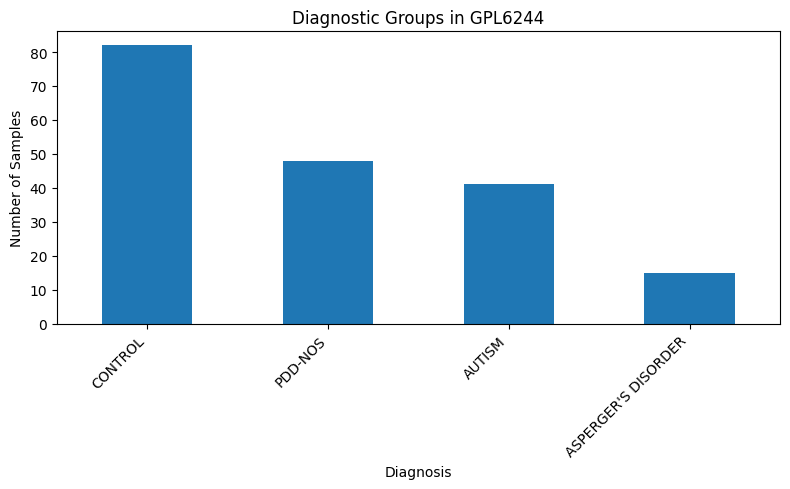

In [14]:
import matplotlib.pyplot as plt

diagnosis_counts = metadata["diagnosis"].value_counts()

plt.figure(figsize=(8, 5))
diagnosis_counts.plot(kind="bar")
plt.title("Diagnostic Groups in GPL6244")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
metadata["gender"].value_counts(dropna=False)

gender
male      128
female     58
Name: count, dtype: int64

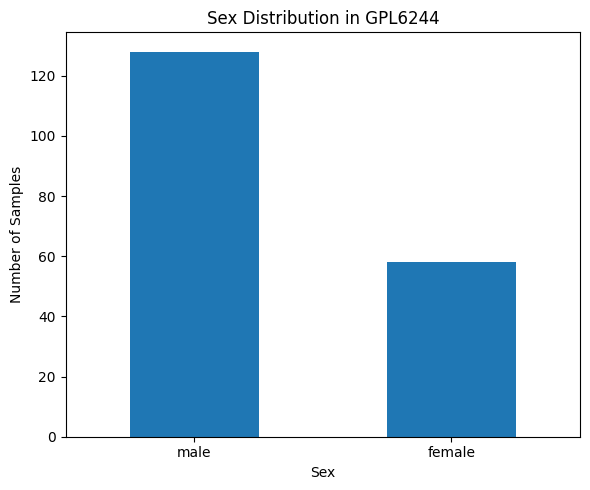

In [16]:
gender_counts = metadata["gender"].value_counts()

plt.figure(figsize=(6, 5))
gender_counts.plot(kind="bar")
plt.title("Sex Distribution in GPL6244")
plt.xlabel("Sex")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
pd.crosstab(
    metadata["diagnosis"],
    metadata["gender"]
)

gender,female,male
diagnosis,,
ASPERGER'S DISORDER,2,13
AUTISM,10,31
CONTROL,34,48
PDD-NOS,12,36


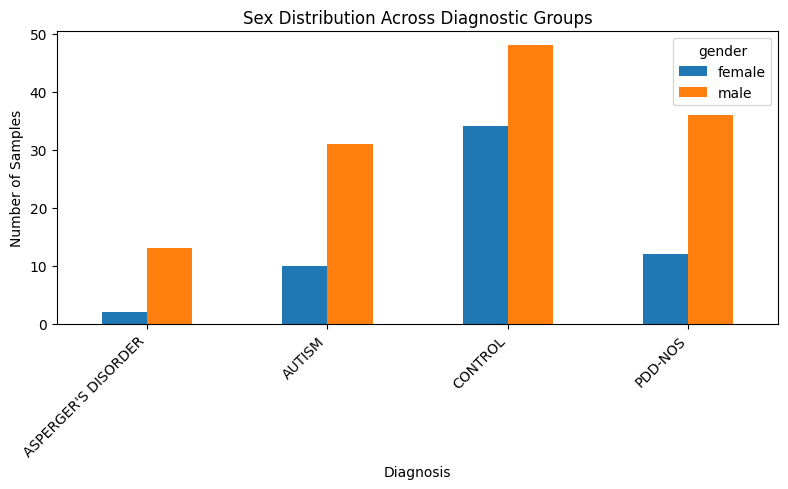

In [18]:
sex_by_diagnosis = pd.crosstab(
    metadata["diagnosis"],
    metadata["gender"]
)

sex_by_diagnosis.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sex Distribution Across Diagnostic Groups")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Binary Diagnostic Group

For binary classification, the three ASD diagnostic subtypes (Autism, Asperger's Disorder, and PDD-NOS) are grouped as ASD, while the control samples are retained as the Control group.

In [19]:
# Create a binary diagnostic label

metadata["group"] = metadata["diagnosis"].apply(
    lambda x: "Control" if x == "CONTROL" else "ASD"
)

metadata["group"].value_counts()

group
ASD        104
Control     82
Name: count, dtype: int64

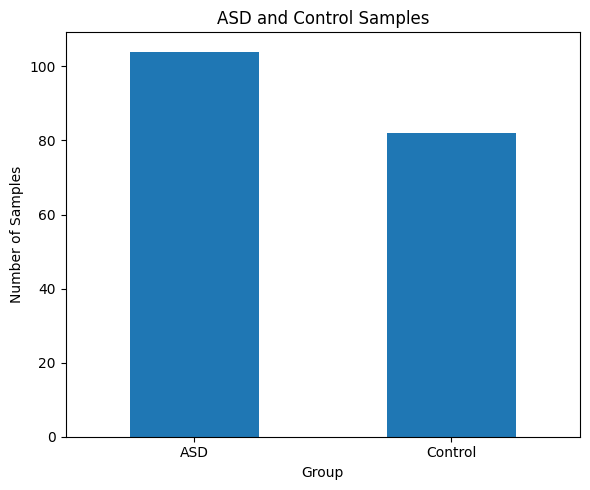

In [20]:
group_counts = metadata["group"].value_counts()

plt.figure(figsize=(6, 5))
group_counts.plot(kind="bar")
plt.title("ASD and Control Samples")
plt.xlabel("Group")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
metadata["age_months"] = pd.to_numeric(
    metadata["age at blood drawing (months)"],
    errors="coerce"
)

metadata["age_months"].describe()

count    186.000000
mean      96.806452
std       52.409460
min       24.000000
25%       51.250000
50%       84.000000
75%      136.500000
max      264.000000
Name: age_months, dtype: float64

In [22]:
print("Missing age:", metadata["age_months"].isna().sum())

Missing age: 0


In [23]:
metadata.groupby("group")["age_months"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
ASD,104.0,97.096154,48.612300,24.0,60.0,87.5,132.0,252.0
Control,82.0,96.439024,57.168172,24.0,49.0,80.0,144.0,264.0


<Figure size 700x500 with 0 Axes>

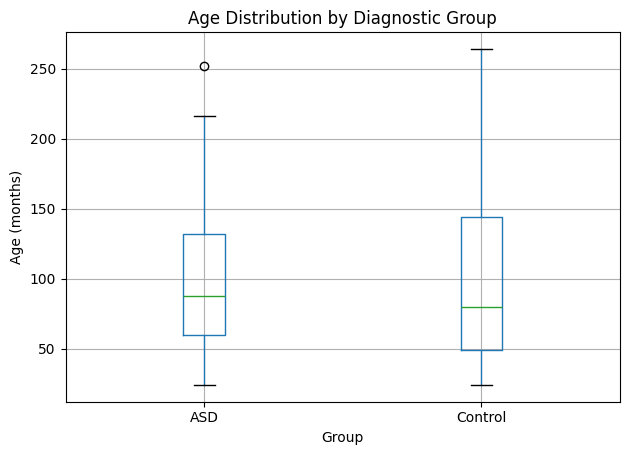

In [24]:
plt.figure(figsize=(7, 5))

metadata.boxplot(
    column="age_months",
    by="group"
)

plt.title("Age Distribution by Diagnostic Group")
plt.suptitle("")
plt.xlabel("Group")
plt.ylabel("Age (months)")
plt.tight_layout()
plt.show()

## 3. Clean Sample Metadata

A cleaned sample-level metadata table was created containing the variables required for downstream analysis, including sample ID, diagnosis, binary diagnostic group, sex, age, and platform.

In [25]:
metadata_clean = metadata[
    [
        "sample_id",
        "diagnosis",
        "group",
        "gender",
        "age_months",
        "platform",
        "source"
    ]
].copy()

metadata_clean.head()

,sample_id,diagnosis,group,gender,age_months,platform,source
0,GSM650655,ASPERGER'S DISORDER,ASD,male,156,GPL6244,Blood
1,GSM650656,AUTISM,ASD,male,168,GPL6244,Blood
2,GSM650657,CONTROL,Control,male,228,GPL6244,Blood
3,GSM650658,AUTISM,ASD,male,60,GPL6244,Blood
4,GSM650659,AUTISM,ASD,male,36,GPL6244,Blood


In [26]:
metadata_clean.shape

(186, 7)

In [27]:
metadata_path = "../data/metadata/sample_metadata.csv"

metadata_clean.to_csv(
    metadata_path,
    index=False
)

print(f"Saved metadata to: {metadata_path}")

Saved metadata to: ../data/metadata/sample_metadata.csv


## 4. Expression Data Extraction

Expression measurements were extracted for the 186 samples profiled on GPL6244.

The resulting matrix will contain probes as rows and samples as columns and will be used as the starting point for downstream preprocessing and feature selection.

In [28]:
# Extract expression tables for GPL6244 samples

expression_tables = []

for sample_id in GPL6244_SAMPLES:
    gsm = gse.gsms[sample_id]
    
    table = gsm.table.copy()
    table["sample_id"] = sample_id
    
    expression_tables.append(table)

print(f"Number of expression tables: {len(expression_tables)}")

Number of expression tables: 186


In [29]:
expression_tables[0].head()

,ID_REF,VALUE,sample_id
0,7892501,9.67160,GSM650655
1,7892502,122.91175,GSM650655
2,7892503,151.17249,GSM650655
3,7892504,1935.89058,GSM650655
4,7892505,21.14810,GSM650655


In [30]:
expression_tables[0].columns.tolist()

['ID_REF', 'VALUE', 'sample_id']

In [31]:
# Build probe × sample expression matrix

expression_matrix = pd.concat(
    [
        table.set_index("ID_REF")["VALUE"].rename(sample_id)
        for table, sample_id in zip(expression_tables, GPL6244_SAMPLES)
    ],
    axis=1
)

print("Expression matrix shape:", expression_matrix.shape)
expression_matrix.head()

Expression matrix shape: (33297, 186)


,GSM650655,GSM650656,GSM650657,GSM650658,GSM650659,GSM650660,GSM650661,GSM650662,GSM650663,GSM650664,...,GSM650944,GSM650946,GSM650950,GSM650951,GSM650954,GSM650959,GSM650968,GSM650969,GSM650970,GSM650975
ID_REF,,,,,,,,,,,,,,,,,,,,,
7892501,9.67160,79.14403,5.01300,25.72981,13.91895,50.35127,0.00710,21.05778,17.47698,21.28318,...,3.29406,11.12443,10.39181,8.97071,10.81198,4.68356,6.86785,17.74369,25.06523,0.20273
7892502,122.91175,104.38295,72.69745,145.16537,135.98053,175.38919,76.26821,132.59755,71.81705,111.28992,...,91.05885,111.46063,122.56646,114.05913,118.40833,108.89500,116.92853,81.63403,125.67404,162.58068
7892503,151.17249,67.21808,121.55192,95.46856,142.72005,139.20885,76.43104,129.48506,28.21930,117.98628,...,68.07263,33.71550,37.54560,55.18136,51.72213,43.75254,39.59656,53.28886,52.58810,41.59902
7892504,1935.89058,1302.83223,2160.06200,1962.15620,2244.96492,1881.05895,1872.58446,2172.58165,1855.87522,2178.26544,...,911.73272,938.98578,966.40733,968.54483,952.49003,1265.23364,1218.08127,1268.45347,1394.62097,1005.47667
7892505,21.14810,13.81453,23.37327,21.44558,20.51383,34.54137,21.32496,20.20900,18.05306,31.27404,...,19.42496,12.85209,16.61253,22.24478,21.30586,14.24507,18.37833,20.56806,21.40529,17.12014


In [32]:
print(
    "Total missing values:",
    expression_matrix.isna().sum().sum()
)

Total missing values: 0


In [33]:
print(
    "Duplicated probe IDs:",
    expression_matrix.index.duplicated().sum()
)

Duplicated probe IDs: 0


In [34]:
expression_matrix.dtypes.value_counts()

float64    186
Name: count, dtype: int64

In [35]:
expression_matrix.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
GSM650655,33297.0,355.714150,904.134076,0.00044,46.90279,119.69605,306.81613,21551.26666
GSM650656,33297.0,368.801310,928.983572,0.00045,46.49345,114.83118,312.02414,20878.30615
GSM650657,33297.0,336.702424,883.373264,0.00044,63.81039,132.38325,281.42850,25155.54134
GSM650658,33297.0,369.290563,927.125834,0.00033,62.18270,138.46939,317.51090,22004.19270
GSM650659,33297.0,359.086663,908.202135,0.00044,56.64695,130.98528,306.95448,22271.17774


### Expression Distribution Across Samples

The distribution of expression values was examined across samples to identify major differences in overall signal intensity and potential technical outliers.

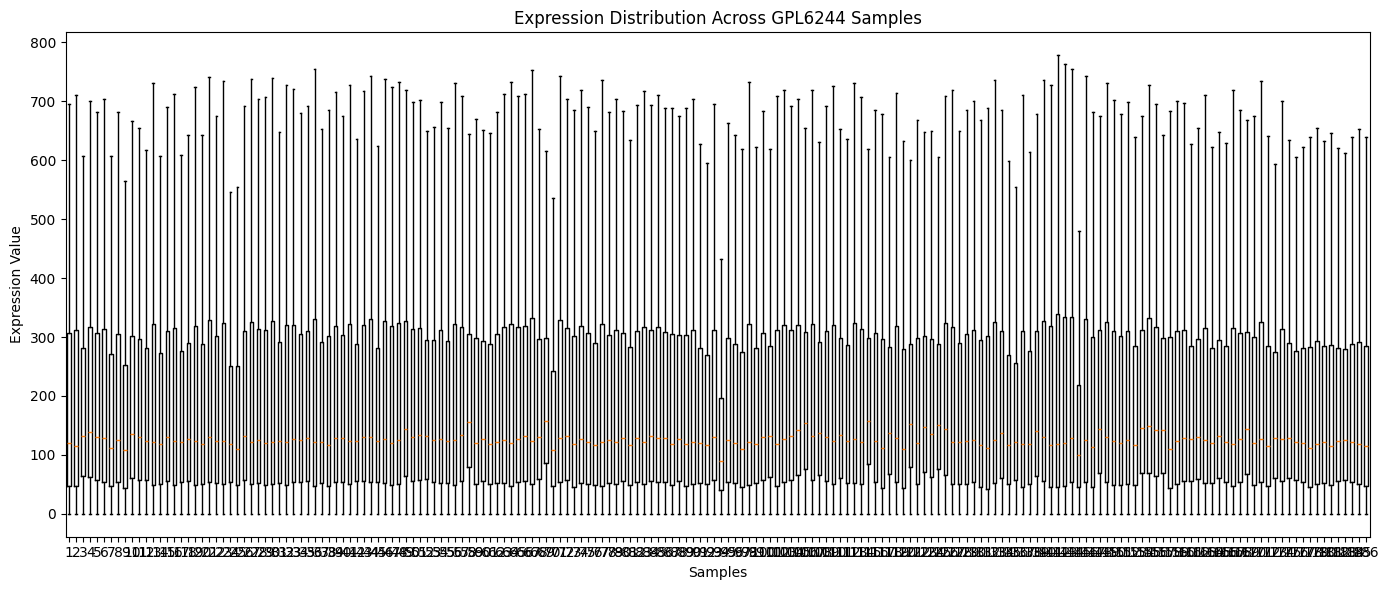

In [36]:
plt.figure(figsize=(14, 6))

plt.boxplot(
    expression_matrix.values,
    showfliers=False
)

plt.title("Expression Distribution Across GPL6244 Samples")
plt.xlabel("Samples")
plt.ylabel("Expression Value")

plt.tight_layout()
plt.show()

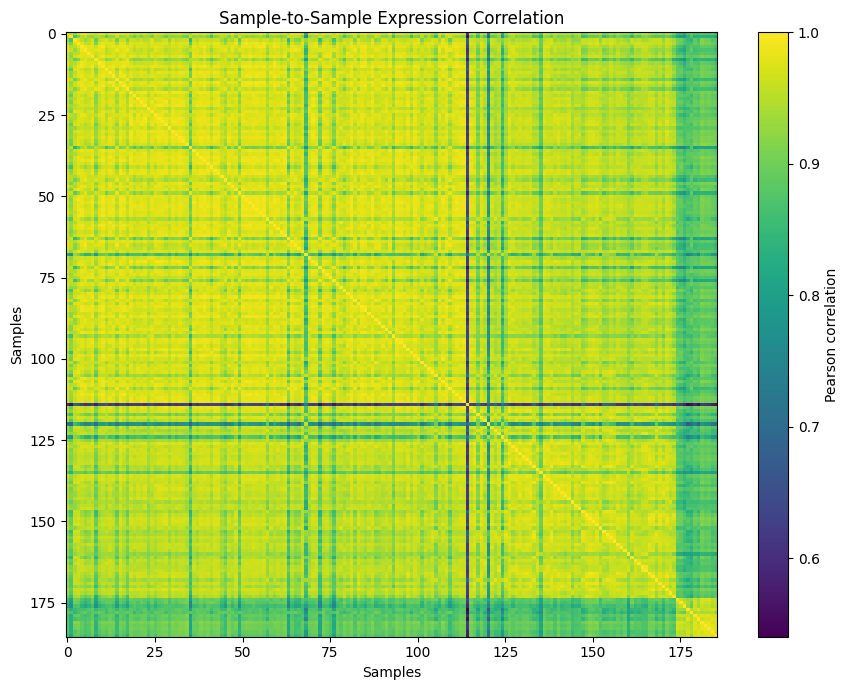

In [37]:
sample_correlation = expression_matrix.corr()

plt.figure(figsize=(9, 7))

plt.imshow(
    sample_correlation,
    aspect="auto"
)

plt.colorbar(label="Pearson correlation")
plt.title("Sample-to-Sample Expression Correlation")
plt.xlabel("Samples")
plt.ylabel("Samples")

plt.tight_layout()
plt.show()

## Probe Annotation and Gene Mapping

The expression matrix contains probe-level measurements from the Affymetrix Human Gene 1.0 ST Array (GPL6244).

Before downstream statistical analysis and machine learning, probes need to be mapped to gene identifiers. This step is important because multiple probes may correspond to the same gene, and some probes may not have a valid gene annotation.

We therefore first inspect the GPL6244 platform annotation and determine which identifiers are available for mapping probes to genes.

In [38]:
platform = gse.gpls["GPL6244"]

print(platform.table.shape)
print(platform.table.columns.tolist())

(33297, 12)
['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


## Inspecting Probe-to-Gene Annotation

The GPL6244 platform annotation provides a `gene_assignment` field for each probe. We inspect representative entries to determine the annotation format before performing probe-to-gene mapping.

In [39]:
annotation = platform.table.copy()

annotation[["ID", "gene_assignment", "mrna_assignment", "category"]].head(10)

,ID,gene_assignment,mrna_assignment,category
0,7896736,---,NONHSAT060105 // NONCODE // Non-coding transcr...,main
1,7896738,ENST00000328113 // OR4G2P // olfactory recepto...,ENST00000328113 // ENSEMBL // havana:known chr...,main
2,7896740,"NM_001004195 // OR4F4 // olfactory receptor, f...",NM_001004195 // RefSeq // Homo sapiens olfacto...,main
3,7896742,NR_024437 // LOC728323 // uncharacterized LOC7...,NR_024437 // RefSeq // Homo sapiens uncharacte...,main
4,7896744,"NM_001005221 // OR4F29 // olfactory receptor, ...",NM_001005221 // RefSeq // Homo sapiens olfacto...,main
5,7896746,ENST00000387377 // MT-TM // mitochondrially en...,ENST00000387377 // ENSEMBL // mt_genbank_impor...,main
6,7896748,ENST00000387382 // MT-TW // mitochondrially en...,ENST00000387382 // ENSEMBL // mt_genbank_impor...,main
7,7896750,ENST00000387419 // MT-TD // mitochondrially en...,ENST00000387419 // ENSEMBL // mt_genbank_impor...,main
8,7896752,ENST00000387421 // MT-TK // mitochondrially en...,ENST00000387421 // ENSEMBL // mt_genbank_impor...,main
9,7896754,ENST00000540997 // LOC100287497 // uncharacter...,ENST00000540997 // ENSEMBL // havana:known chr...,main


In [40]:
annotation["gene_assignment"].head(20).tolist()

['---',
 'ENST00000328113 // OR4G2P // olfactory receptor, family 4, subfamily G, member 2 pseudogene // --- // --- /// ENST00000492842 // OR4G11P // olfactory receptor, family 4, subfamily G, member 11 pseudogene // --- // --- /// ENST00000588632 // OR4G1P // olfactory receptor, family 4, subfamily G, member 1 pseudogene // --- // ---',
 'NM_001004195 // OR4F4 // olfactory receptor, family 4, subfamily F, member 4 // 15q26.3 // 26682 /// NM_001005240 // OR4F17 // olfactory receptor, family 4, subfamily F, member 17 // 19p13.3 // 81099 /// NM_001005484 // OR4F5 // olfactory receptor, family 4, subfamily F, member 5 // 1p36.33 // 79501 /// ENST00000318050 // OR4F17 // olfactory receptor, family 4, subfamily F, member 17 // 19p13.3 // 81099 /// ENST00000326183 // OR4F4 // olfactory receptor, family 4, subfamily F, member 4 // 15q26.3 // 26682 /// ENST00000335137 // OR4F5 // olfactory receptor, family 4, subfamily F, member 5 // 1p36.33 // 79501 /// ENST00000585993 // OR4F17 // olfactory 

## Assessing Probe Annotation Ambiguity

A probe may be annotated to multiple transcripts or genes. To avoid assigning an expression measurement to an incorrect gene, probes with ambiguous mappings to multiple distinct gene symbols will be excluded from the primary gene-level analysis.

First, we quantify the extent of missing and ambiguous gene annotation.

In [41]:
def extract_gene_symbols(annotation_string):
    if pd.isna(annotation_string) or annotation_string == "---":
        return []
    
    records = annotation_string.split(" /// ")
    gene_symbols = []
    
    for record in records:
        fields = [field.strip() for field in record.split(" // ")]
        
        if len(fields) >= 2:
            gene_symbol = fields[1]
            
            if gene_symbol not in {"---", ""}:
                gene_symbols.append(gene_symbol)
    
    return sorted(set(gene_symbols))


annotation["gene_symbols"] = annotation["gene_assignment"].apply(
    extract_gene_symbols
)

annotation["n_gene_symbols"] = annotation["gene_symbols"].apply(len)

print("Total probes:", len(annotation))
print("Probes with no gene annotation:", (annotation["n_gene_symbols"] == 0).sum())
print("Probes mapped to exactly one gene:", (annotation["n_gene_symbols"] == 1).sum())
print("Probes mapped to multiple genes:", (annotation["n_gene_symbols"] > 1).sum())

Total probes: 33297
Probes with no gene annotation: 8004
Probes mapped to exactly one gene: 22153
Probes mapped to multiple genes: 3140


In [42]:
annotation.loc[
    annotation["n_gene_symbols"] > 1,
    ["ID", "gene_symbols"]
].head(10)

,ID,gene_symbols
1,7896738,"[OR4G11P, OR4G1P, OR4G2P]"
2,7896740,"[OR4F17, OR4F4, OR4F5]"
3,7896742,"[LINC00266-1, LINC00266-2P, LINC00266-3, LINC0..."
4,7896744,"[OR4F16, OR4F1P, OR4F21, OR4F28P, OR4F29, OR4F..."
9,7896754,"[LOC100287497, LOC100287934, LOC101930657]"
10,7896756,"[FAM87A, FAM87B]"
27,7896937,"[ATAD3A, ATAD3B, ATAD3C]"
28,7896952,"[ATAD3A, ATAD3B]"
29,7896961,"[ATAD3A, ATAD3B, ATAD3C]"
32,7897006,"[MMP23A, MMP23B]"


## Filtering to Unambiguous Probe-to-Gene Mappings

For the primary analysis, we retain only probes that map unambiguously to a single gene symbol.

Probes without a gene annotation and probes mapped to multiple distinct genes are excluded from the primary gene-level analysis. This conservative strategy reduces the risk of assigning a probe expression profile to the wrong gene.

In [43]:
unambiguous_annotation = annotation[
    annotation["n_gene_symbols"] == 1
].copy()

unambiguous_annotation["gene_symbol"] = (
    unambiguous_annotation["gene_symbols"].str[0]
)

print("Unambiguous probes:", len(unambiguous_annotation))
print(
    "Unique genes represented:",
    unambiguous_annotation["gene_symbol"].nunique()
)

Unambiguous probes: 22153
Unique genes represented: 21408


In [44]:
unambiguous_annotation[
    ["ID", "gene_symbol"]
].head(10)

,ID,gene_symbol
5,7896746,MT-TM
6,7896748,MT-TW
7,7896750,MT-TD
8,7896752,MT-TK
11,7896759,LINC01128
12,7896761,SAMD11
13,7896779,KLHL17
14,7896798,PLEKHN1
15,7896817,ISG15
16,7896822,AGRN


In [45]:
probe_counts_per_gene = (
    unambiguous_annotation["gene_symbol"]
    .value_counts()
)

print("Genes with one probe:", (probe_counts_per_gene == 1).sum())
print("Genes with multiple probes:", (probe_counts_per_gene > 1).sum())
print("Maximum probes for one gene:", probe_counts_per_gene.max())

Genes with one probe: 20833
Genes with multiple probes: 575
Maximum probes for one gene: 26


## Aggregating Multiple Probes at the Gene Level

After restricting the analysis to unambiguous probe-to-gene mappings, multiple probes may still represent the same gene.

To obtain one expression feature per gene, expression values from probes targeting the same gene are aggregated using the median across probes. The median is a robust summary that reduces the influence of unusually high or low probe-level measurements.

This produces a gene-level expression matrix suitable for downstream statistical analysis and machine learning.

In [46]:
# Keep only probes with an unambiguous gene mapping
probe_expression = expression_matrix.loc[
    unambiguous_annotation["ID"]
].copy()

# Replace probe IDs with gene symbols
probe_expression["gene_symbol"] = (
    unambiguous_annotation
    .set_index("ID")
    .loc[probe_expression.index, "gene_symbol"]
)

# Aggregate multiple probes belonging to the same gene
gene_expression = (
    probe_expression
    .drop(columns="gene_symbol")
    .groupby(probe_expression["gene_symbol"])
    .median()
)

print("Gene-level expression matrix shape:", gene_expression.shape)

Gene-level expression matrix shape: (21408, 186)


In [47]:
print("Number of genes:", gene_expression.shape[0])
print("Number of samples:", gene_expression.shape[1])
print("Missing values:", gene_expression.isna().sum().sum())

Number of genes: 21408
Number of samples: 186
Missing values: 0


## Assessing the Gene-Level Expression Scale

The GPL6244 expression data were processed using the Probe Logarithmic Intensity Error (PLIER) method. Therefore, an additional log transformation should not be applied without first examining the distribution and numerical scale of the resulting gene-level expression matrix.

We inspect summary statistics and the distribution of gene-level expression values to determine whether an additional transformation is appropriate.

In [48]:
print("Minimum:", gene_expression.min().min())
print("Maximum:", gene_expression.max().max())
print("Median:", gene_expression.median().median())
print("Mean:", gene_expression.mean().mean())

Minimum: 0.00024
Maximum: 167654.0977
Median: 127.0873075
Mean: 258.33359687946023


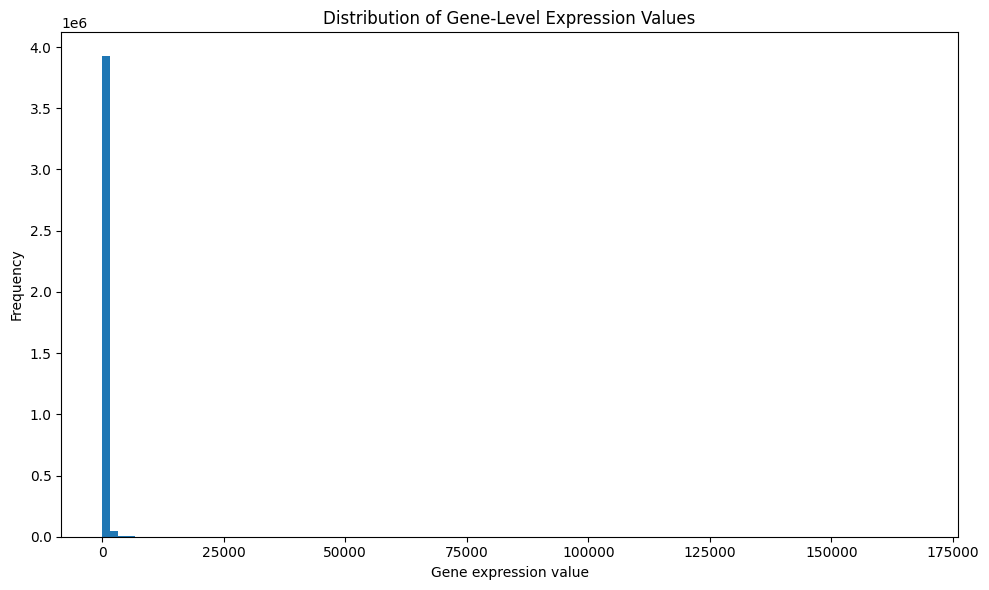

In [49]:
plt.figure(figsize=(10, 6))

plt.hist(
    gene_expression.values.flatten(),
    bins=100
)

plt.xlabel("Gene expression value")
plt.ylabel("Frequency")
plt.title("Distribution of Gene-Level Expression Values")

plt.tight_layout()
plt.show()

## Inspecting Expression Distribution on a Logarithmic Scale

The gene-level expression values show a strongly right-skewed distribution, with a median of approximately 127 and a maximum above 167,000.

Because the dataset was already processed using PLIER, the original expression matrix will not be transformed at this stage. Instead, a log2-transformed copy is used only for visualization to better assess the overall distribution.

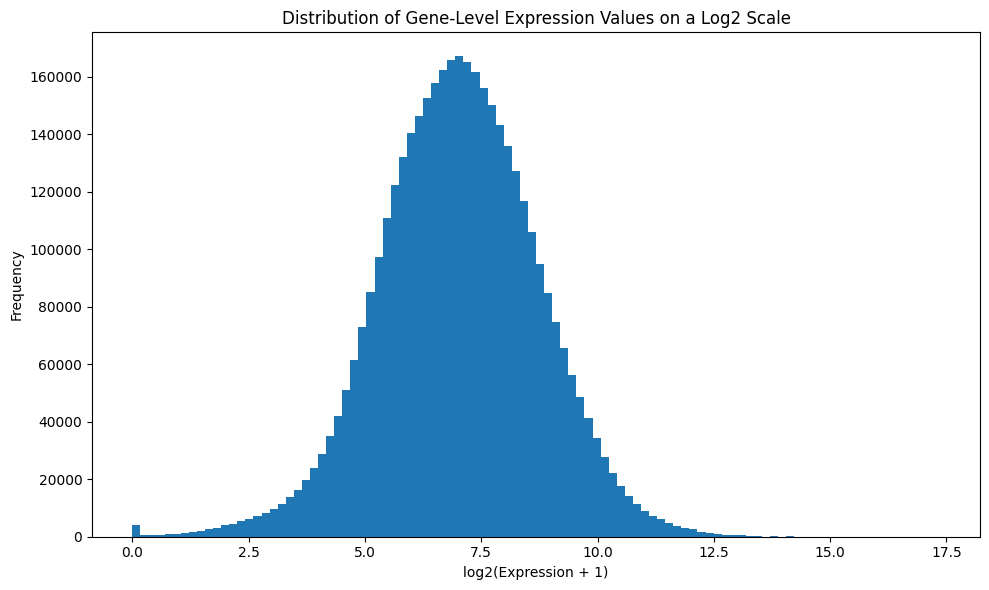

In [50]:
gene_expression_log2 = np.log2(gene_expression + 1)

plt.figure(figsize=(10, 6))

plt.hist(
    gene_expression_log2.values.flatten(),
    bins=100
)

plt.xlabel("log2(Expression + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Gene-Level Expression Values on a Log2 Scale")

plt.tight_layout()
plt.show()

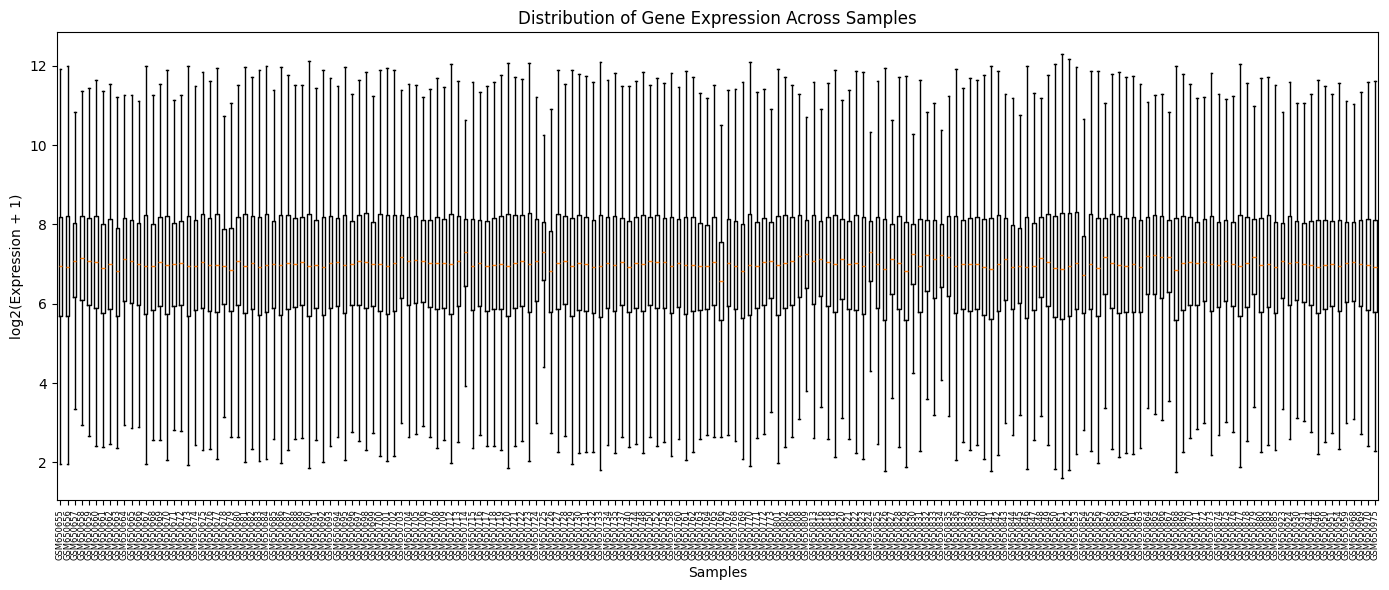

In [51]:
plt.figure(figsize=(14, 6))

plt.boxplot(
    gene_expression_log2.values,
    showfliers=False
)

plt.xlabel("Samples")
plt.ylabel("log2(Expression + 1)")
plt.title("Distribution of Gene Expression Across Samples")
plt.xticks(
    ticks=np.arange(1, len(gene_expression_log2.columns) + 1),
    labels=gene_expression_log2.columns,
    rotation=90,
    fontsize=6
)

plt.tight_layout()
plt.show()

In [52]:
sample_qc = pd.DataFrame({
    "median": gene_expression_log2.median(axis=0),
    "mean": gene_expression_log2.mean(axis=0),
    "std": gene_expression_log2.std(axis=0),
    "q1": gene_expression_log2.quantile(0.25, axis=0),
    "q3": gene_expression_log2.quantile(0.75, axis=0)
})

sample_qc["IQR"] = sample_qc["q3"] - sample_qc["q1"]

sample_qc.sort_values("median")

,median,mean,std,q1,q3,IQR
GSM650766,6.575931,6.547754,1.666764,5.592481,7.558672,1.966191
GSM650854,6.731452,6.695373,1.675696,5.756579,7.712874,1.956295
GSM650829,6.823384,6.781519,1.899023,5.585260,8.049471,2.464211
GSM650663,6.827456,6.770556,1.714318,5.686874,7.899419,2.212545
GSM650769,6.832801,6.804517,1.805089,5.642584,8.019688,2.377105
...,...,...,...,...,...,...
GSM650809,7.258976,7.252863,1.411919,6.391423,8.119063,1.727640
GSM650830,7.261706,7.223386,1.354404,6.503205,8.010377,1.507172
GSM650714,7.291272,7.281232,1.407681,6.448108,8.124804,1.676696
GSM650725,7.304697,7.312908,1.314433,6.593095,8.059298,1.466202


In [53]:
print("Median range:")
print(sample_qc["median"].min(), "to", sample_qc["median"].max())

print("\nIQR range:")
print(sample_qc["IQR"].min(), "to", sample_qc["IQR"].max())

Median range:
6.575930668684436 to 7.304716686515855

IQR range:
1.4662021704250714 to 2.6870452089514156


In [54]:
print("Lowest median samples:")
print(sample_qc.nsmallest(5, "median"))

print("\nHighest median samples:")
print(sample_qc.nlargest(5, "median"))

Lowest median samples:
             median      mean       std        q1        q3       IQR
GSM650766  6.575931  6.547754  1.666764  5.592481  7.558672  1.966191
GSM650854  6.731452  6.695373  1.675696  5.756579  7.712874  1.956295
GSM650829  6.823384  6.781519  1.899023  5.585260  8.049471  2.464211
GSM650663  6.827456  6.770556  1.714318  5.686874  7.899419  2.212545
GSM650769  6.832801  6.804517  1.805089  5.642584  8.019688  2.377105

Highest median samples:
             median      mean       std        q1        q3       IQR
GSM650824  7.304717  7.314305  1.314593  6.569751  8.075561  1.505810
GSM650725  7.304697  7.312908  1.314433  6.593095  8.059298  1.466202
GSM650714  7.291272  7.281232  1.407681  6.448108  8.124804  1.676696
GSM650830  7.261706  7.223386  1.354404  6.503205  8.010377  1.507172
GSM650809  7.258976  7.252863  1.411919  6.391423  8.119063  1.727640


In [55]:
from sklearn.decomposition import PCA

# Samples × genes
X_pca = gene_expression_log2.T

pca = PCA(n_components=10)
X_pca_result = pca.fit_transform(X_pca)

explained_variance = pca.explained_variance_ratio_

print("Explained variance by first 10 PCs:")
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f} ({variance * 100:.2f}%)")

Explained variance by first 10 PCs:
PC1: 0.2902 (29.02%)
PC2: 0.0971 (9.71%)
PC3: 0.0864 (8.64%)
PC4: 0.0522 (5.22%)
PC5: 0.0414 (4.14%)
PC6: 0.0246 (2.46%)
PC7: 0.0185 (1.85%)
PC8: 0.0163 (1.63%)
PC9: 0.0146 (1.46%)
PC10: 0.0132 (1.32%)


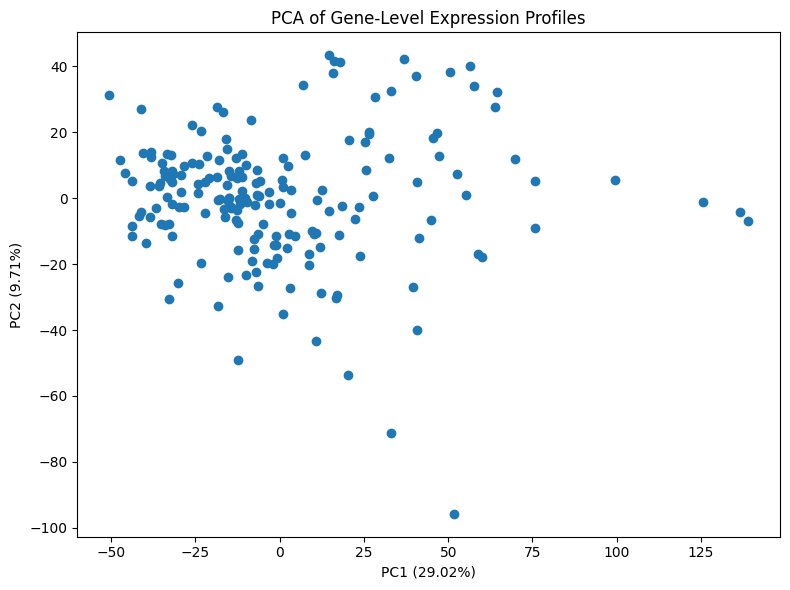

In [56]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_result[:, 0],
    X_pca_result[:, 1]
)

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("PCA of Gene-Level Expression Profiles")

plt.tight_layout()
plt.show()

In [57]:
pca_metadata = metadata_clean.set_index("sample_id").loc[
    gene_expression_log2.columns
]

pca_metadata[["group", "gender"]].head()

,group,gender
GSM650655,ASD,male
GSM650656,ASD,male
GSM650657,Control,male
GSM650658,ASD,male
GSM650659,ASD,male


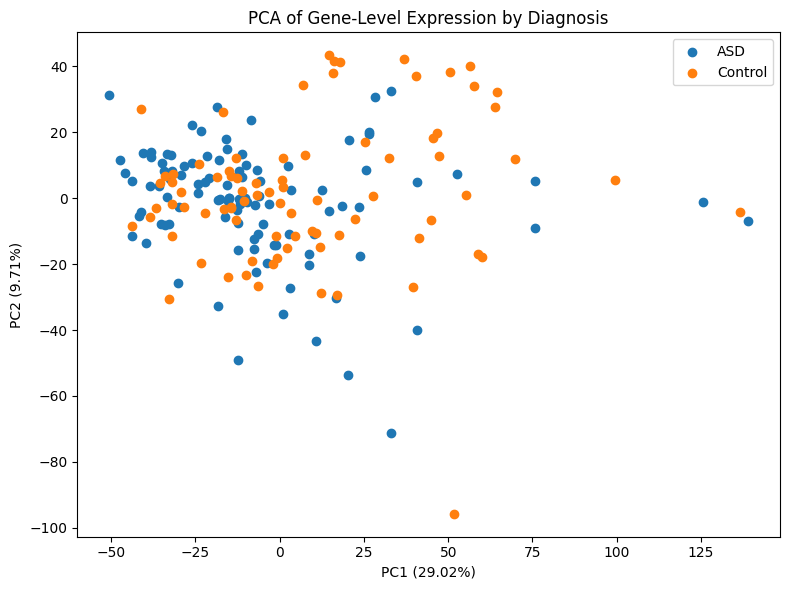

In [58]:
plt.figure(figsize=(8, 6))

for group in pca_metadata["group"].unique():
    mask = pca_metadata["group"] == group
    
    plt.scatter(
        X_pca_result[mask, 0],
        X_pca_result[mask, 1],
        label=group
    )

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("PCA of Gene-Level Expression by Diagnosis")
plt.legend()

plt.tight_layout()
plt.show()

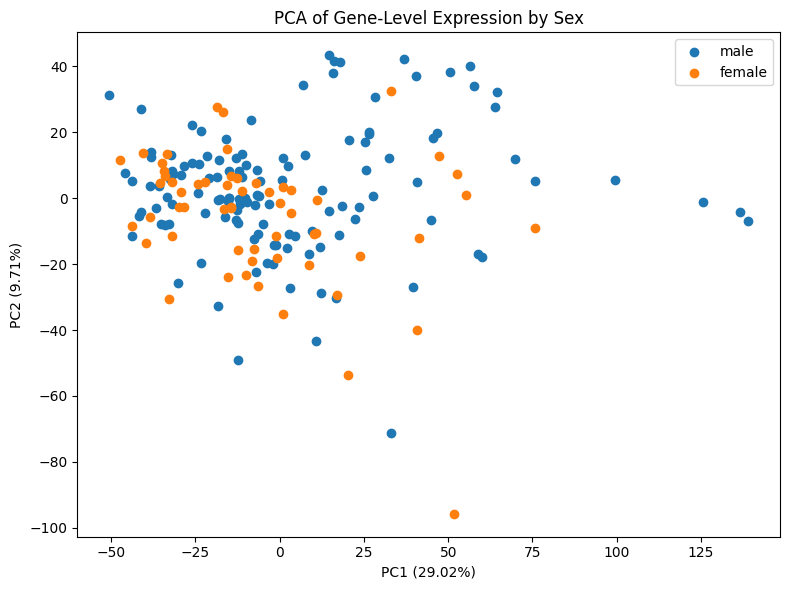

In [59]:
plt.figure(figsize=(8, 6))

for gender in pca_metadata["gender"].unique():
    mask = pca_metadata["gender"] == gender
    
    plt.scatter(
        X_pca_result[mask, 0],
        X_pca_result[mask, 1],
        label=gender
    )

plt.xlabel(f"PC1 ({explained_variance[0] * 100:.2f}%)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.2f}%)")
plt.title("PCA of Gene-Level Expression by Sex")
plt.legend()

plt.tight_layout()
plt.show()

In [60]:
from scipy.spatial.distance import euclidean

# Use the first 5 principal components
pca_coordinates = X_pca_result[:, :5]

pca_distance = np.sqrt(
    np.sum(
        (pca_coordinates - pca_coordinates.mean(axis=0)) ** 2,
        axis=1
    )
)

pca_outlier_check = pd.DataFrame({
    "sample_id": gene_expression_log2.columns,
    "PC_distance": pca_distance
})

pca_outlier_check = pca_outlier_check.sort_values(
    "PC_distance",
    ascending=False
)

pca_outlier_check.head(10)

,sample_id,PC_distance
120,GSM650830,142.957423
114,GSM650824,140.975806
68,GSM650725,130.536033
93,GSM650766,121.158376
124,GSM650834,105.599393
175,GSM650931,91.750124
182,GSM650968,88.409567
144,GSM650854,88.228568
176,GSM650944,87.808830
181,GSM650959,85.150994


In [61]:
print("PCA distance summary:")
print(pca_outlier_check["PC_distance"].describe())

PCA distance summary:
count    186.000000
mean      41.417200
std       23.108387
min        9.510355
25%       26.745317
50%       35.547519
75%       50.325612
max      142.957423
Name: PC_distance, dtype: float64


In [62]:
pca_outlier_check = pca_outlier_check.merge(
    metadata_clean[["sample_id", "group", "gender", "age_months"]],
    on="sample_id",
    how="left"
)

pca_outlier_check.head(10)

,sample_id,PC_distance,group,gender,age_months
0,GSM650830,142.957423,ASD,male,36
1,GSM650824,140.975806,Control,male,176
2,GSM650725,130.536033,ASD,male,132
3,GSM650766,121.158376,Control,female,148
4,GSM650834,105.599393,Control,male,36
5,GSM650931,91.750124,Control,male,143
6,GSM650968,88.409567,Control,male,51
7,GSM650854,88.228568,ASD,male,77
8,GSM650944,87.808830,Control,male,85
9,GSM650959,85.150994,Control,male,28


In [63]:
pca_analysis = pd.DataFrame(
    X_pca_result[:, :5],
    index=gene_expression_log2.columns,
    columns=[f"PC{i}" for i in range(1, 6)]
)

pca_analysis = pca_analysis.join(
    metadata_clean.set_index("sample_id")[[
        "group",
        "gender",
        "age_months"
    ]]
)

pca_analysis.head()

,PC1,PC2,PC3,PC4,PC5,group,gender,age_months
GSM650655,-34.081961,-8.064259,-0.920088,12.546233,4.696446,ASD,male,156
GSM650656,-32.678222,-7.883331,12.394930,37.786925,-32.103546,ASD,male,168
GSM650657,58.864835,-16.920493,-1.850296,-5.752371,9.076924,Control,male,228
GSM650658,25.637870,8.392644,7.956647,-0.087970,15.219638,ASD,male,60
GSM650659,-3.031544,-1.753031,14.273880,14.144165,-0.581959,ASD,male,36


In [64]:
age_correlations = pca_analysis[
    ["PC1", "PC2", "PC3", "PC4", "PC5"]
].corrwith(
    pca_analysis["age_months"]
)

print("Correlation between age and principal components:")
print(age_correlations)

Correlation between age and principal components:
PC1    0.041248
PC2   -0.284631
PC3    0.013977
PC4   -0.128717
PC5    0.361388
dtype: float64


In [65]:
from scipy.stats import mannwhitneyu

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    
    asd = pca_analysis.loc[
        pca_analysis["group"] == "ASD", pc
    ]
    
    control = pca_analysis.loc[
        pca_analysis["group"] == "Control", pc
    ]
    
    female = pca_analysis.loc[
        pca_analysis["gender"] == "female", pc
    ]
    
    male = pca_analysis.loc[
        pca_analysis["gender"] == "male", pc
    ]
    
    _, p_group = mannwhitneyu(
        asd,
        control,
        alternative="two-sided"
    )
    
    _, p_sex = mannwhitneyu(
        female,
        male,
        alternative="two-sided"
    )
    
    print(
        f"{pc}: "
        f"ASD vs Control p={p_group:.4g}, "
        f"Female vs Male p={p_sex:.4g}"
    )

PC1: ASD vs Control p=0.0005909, Female vs Male p=0.1777
PC2: ASD vs Control p=0.7204, Female vs Male p=0.0104
PC3: ASD vs Control p=0.03672, Female vs Male p=0.4213
PC4: ASD vs Control p=0.6439, Female vs Male p=0.1684
PC5: ASD vs Control p=0.5201, Female vs Male p=0.4029


## Multiple-Testing Correction for PCA Associations

We tested the associations of the first five principal components with diagnostic group and sex. Benjamini–Hochberg correction is applied separately to the five diagnostic-group tests and the five sex tests to account for multiple comparisons.


In [66]:

import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

results = []

for pc in ["PC1", "PC2", "PC3", "PC4", "PC5"]:
    asd = pca_analysis.loc[
        pca_analysis["group"] == "ASD", pc
    ]
    control = pca_analysis.loc[
        pca_analysis["group"] == "Control", pc
    ]

    female = pca_analysis.loc[
        pca_analysis["gender"].str.lower() == "female", pc
    ]
    male = pca_analysis.loc[
        pca_analysis["gender"].str.lower() == "male", pc
    ]

    _, p_group = mannwhitneyu(
        asd, control, alternative="two-sided"
    )
    _, p_sex = mannwhitneyu(
        female, male, alternative="two-sided"
    )

    results.append({
        "PC": pc,
        "ASD_vs_Control_p": p_group,
        "Female_vs_Male_p": p_sex
    })

pc_tests = pd.DataFrame(results)

pc_tests["ASD_vs_Control_FDR"] = multipletests(
    pc_tests["ASD_vs_Control_p"],
    method="fdr_bh"
)[1]

pc_tests["Female_vs_Male_FDR"] = multipletests(
    pc_tests["Female_vs_Male_p"],
    method="fdr_bh"
)[1]

pc_tests.round(4)

,PC,ASD_vs_Control_p,Female_vs_Male_p,ASD_vs_Control_FDR,Female_vs_Male_FDR
0,PC1,0.0006,0.1777,0.0030,0.2961
1,PC2,0.7204,0.0104,0.7204,0.0520
2,PC3,0.0367,0.4213,0.0918,0.4213
3,PC4,0.6439,0.1684,0.7204,0.2961
4,PC5,0.5201,0.4029,0.7204,0.4213


## Assessing Age and Sex Differences Between Diagnostic Groups

Age and sex distributions are compared between the ASD and control groups to identify potential confounding factors before machine-learning analysis.


In [67]:

from scipy.stats import mannwhitneyu, chi2_contingency

# Compare age between ASD and Control
asd_age = metadata_clean.loc[
    metadata_clean["group"] == "ASD", "age_months"
].dropna()

control_age = metadata_clean.loc[
    metadata_clean["group"] == "Control", "age_months"
].dropna()

age_stat, age_p = mannwhitneyu(
    asd_age,
    control_age,
    alternative="two-sided"
)

# Compare sex distribution between ASD and Control
sex_table = pd.crosstab(
    metadata_clean["group"],
    metadata_clean["gender"]
)

chi2_stat, sex_p, dof, expected = chi2_contingency(
    sex_table
)

print("Age comparison")
print(f"ASD median age: {asd_age.median():.1f} months")
print(f"Control median age: {control_age.median():.1f} months")
print(f"Mann–Whitney U p-value: {age_p:.4f}")

print("\nSex distribution")
display(sex_table)
print(f"Chi-square p-value: {sex_p:.4f}")
print(f"Minimum expected cell count: {expected.min():.2f}")

Age comparison
ASD median age: 87.5 months
Control median age: 80.0 months
Mann–Whitney U p-value: 0.5568

Sex distribution


gender,female,male
group,,
ASD,24,80
Control,34,48


Chi-square p-value: 0.0115
Minimum expected cell count: 25.57


## Assessing Potential Sex Confounding

The diagnostic groups have significantly different sex distributions (chi-square test, p = 0.0115), whereas no statistically significant age difference was detected (Mann–Whitney U test, p = 0.5568). Sex imbalance may confound downstream classification because gene-expression patterns can differ by sex independently of ASD status. Therefore, sex will be considered explicitly during model development and robustness assessment.


In [68]:
# Prepare samples × genes matrix
X = gene_expression_log2.T

# Align metadata with expression samples
metadata_model = metadata_clean.set_index("sample_id").loc[X.index]

# Define target and covariate
y = metadata_model["group"].map({"Control": 0, "ASD": 1})
sex = metadata_model["gender"].map({"female": 0, "male": 1})

print("Feature matrix:", X.shape)
print("Target distribution:")
print(y.value_counts())
print("\nMissing labels:", y.isna().sum())
print("Missing sex values:", sex.isna().sum())

Feature matrix: (186, 21408)
Target distribution:
group
1    104
0     82
Name: count, dtype: int64

Missing labels: 0
Missing sex values: 0


In [69]:
from sklearn.model_selection import train_test_split

# Stratify by both diagnosis and sex
strata = (
    metadata_model["group"].astype(str)
    + "_"
    + metadata_model["gender"].astype(str)
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=strata
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining: diagnosis × sex")
print(pd.crosstab(
    metadata_model.loc[X_train.index, "group"],
    metadata_model.loc[X_train.index, "gender"]
))

print("\nTest: diagnosis × sex")
print(pd.crosstab(
    metadata_model.loc[X_test.index, "group"],
    metadata_model.loc[X_test.index, "gender"]
))

Training set: (148, 21408)
Test set: (38, 21408)

Training: diagnosis × sex
gender   female  male
group                
ASD          19    64
Control      27    38

Test: diagnosis × sex
gender   female  male
group                
ASD           5    16
Control       7    10


In [70]:
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Preserve diagnosis × sex proportions across CV folds
train_sex = metadata_model.loc[X_train.index, "gender"]
train_group = metadata_model.loc[X_train.index, "group"]

strata_train = train_group.astype(str) + "_" + train_sex.astype(str)

# Stratified folds using diagnosis-sex strata
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = list(cv.split(X_train, strata_train))

# Feature selection and scaling happen separately inside each fold
pipeline = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "select__k": [50, 100, 200, 500],
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}

search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_splits,
    n_jobs=-1,
    refit=True
)

search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(search.best_score_, 3))
print("Best parameters:")
print(search.best_params_)

Best CV ROC-AUC: 0.722
Best parameters:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear', 'select__k': 500}


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [71]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

# Sex-only baseline on training samples
sex_train = (
    metadata_model.loc[X_train.index, "gender"]
    .map({"female": 0, "male": 1})
)

cv_sex = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

sex_model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

sex_scores = cross_val_score(
    sex_model,
    sex_train.to_frame(),
    y_train,
    cv=cv_sex,
    scoring="roc_auc"
)

print("Sex-only CV ROC-AUC:",
      round(sex_scores.mean(), 3), "+/-",
      round(sex_scores.std(), 3))

Sex-only CV ROC-AUC: 0.592 +/- 0.085


In [72]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import pandas as pd

# Add sex as an additional predictor
X_train_sex = X_train.copy()
X_train_sex["sex"] = (
    metadata_model.loc[X_train.index, "gender"]
    .map({"female": 0, "male": 1})
)

# Use the same CV splits and tune the model
combined_pipeline = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

combined_grid = {
    "select__k": [100, 500],
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear"],
    "model__penalty": ["l1", "l2"]
}

combined_search = GridSearchCV(
    combined_pipeline,
    combined_grid,
    scoring="roc_auc",
    cv=cv_splits,
    n_jobs=-1,
    refit=True
)

combined_search.fit(X_train_sex, y_train)

print("Combined model CV ROC-AUC:",
      round(combined_search.best_score_, 3))
print("Best parameters:")
print(combined_search.best_params_)

Combined model CV ROC-AUC: 0.722
Best parameters:
{'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear', 'select__k': 500}


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [73]:
# Check the sex coding and alignment before adjustment
sex_train = (
    metadata_model.loc[X_train.index, "gender"]
    .map({"female": 0, "male": 1})
)

assert X_train.index.equals(y_train.index)
assert X_train.index.equals(sex_train.index)
assert sex_train.notna().all()

print("Training samples:", len(X_train))
print("Gene features:", X_train.shape[1])
print("Sex values:", sex_train.value_counts().to_dict())
print("Sample alignment: OK")

Training samples: 148
Gene features: 21408
Sex values: {1: 102, 0: 46}
Sample alignment: OK


In [74]:
from sklearn.linear_model import LinearRegression

# Estimate the association between sex and each gene's expression
sex_model = LinearRegression()
sex_model.fit(sex_train.to_frame(), X_train)

# Remove the estimated sex effect while preserving each gene's mean
X_train_sex_adjusted = (
    X_train
    - sex_model.predict(sex_train.to_frame())
    + X_train.mean(axis=0)
)

print("Original matrix:", X_train.shape)
print("Sex-adjusted matrix:", X_train_sex_adjusted.shape)
print("Missing values:", X_train_sex_adjusted.isna().sum().sum())

Original matrix: (148, 21408)
Sex-adjusted matrix: (148, 21408)
Missing values: 0


In [75]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Use the existing diagnosis × sex folds
cv_results_adjusted = []

for train_idx, val_idx in cv_splits:
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    sex_fold_train = sex_train.iloc[train_idx]
    sex_fold_val = sex_train.iloc[val_idx]

    # Estimate sex effects using only this fold's training samples
    adjustment = LinearRegression()
    adjustment.fit(sex_fold_train.to_frame(), X_fold_train)

    train_mean = X_fold_train.mean(axis=0)
    X_fold_train_adj = (
        X_fold_train
        - adjustment.predict(sex_fold_train.to_frame())
        + train_mean
    )
    X_fold_val_adj = (
        X_fold_val
        - adjustment.predict(sex_fold_val.to_frame())
        + train_mean
    )

    # Select genes and train the classifier within this fold
    model_fold = Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=500)),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            C=1,
            solver="liblinear",
            penalty="l2",
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        ))
    ])

    model_fold.fit(X_fold_train_adj, y_fold_train)
    val_prob = model_fold.predict_proba(X_fold_val_adj)[:, 1]
    cv_results_adjusted.append(roc_auc_score(y_fold_val, val_prob))

print(
    "Sex-adjusted CV ROC-AUC:",
    f"{np.mean(cv_results_adjusted):.3f} ± {np.std(cv_results_adjusted):.3f}"
)

c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

Sex-adjusted CV ROC-AUC: 0.697 ± 0.055


In [76]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, balanced_accuracy_score,
    recall_score, precision_score, f1_score, confusion_matrix
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
import pandas as pd

# 1. Get sex for training and test samples
sex_train = metadata_model.loc[X_train.index, "gender"].map(
    {"female": 0, "male": 1}
)
sex_test = metadata_model.loc[X_test.index, "gender"].map(
    {"female": 0, "male": 1}
)

# 2. Estimate sex effects using training data only
adjustment = LinearRegression()
adjustment.fit(sex_train.to_frame(), X_train)

train_mean = X_train.mean(axis=0)

X_train_adj = (
    X_train
    - adjustment.predict(sex_train.to_frame())
    + train_mean
)
X_test_adj = (
    X_test
    - adjustment.predict(sex_test.to_frame())
    + train_mean
)

# 3. Fit the selected model on all training samples
final_model = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=500)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        C=1,
        solver="liblinear",
        l1_ratio=0,
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

final_model.fit(X_train_adj, y_train)

# 4. Evaluate once on the untouched test set
y_pred = final_model.predict(X_test_adj)
y_prob = final_model.predict_proba(X_test_adj)[:, 1]

print("Final test results")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_prob):.3f}")
print(f"Accuracy:           {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced accuracy:  {balanced_accuracy_score(y_test, y_pred):.3f}")
print(f"Sensitivity:        {recall_score(y_test, y_pred, zero_division=0):.3f}")
print(f"Precision:          {precision_score(y_test, y_pred, zero_division=0):.3f}")
print(f"F1-score:           {f1_score(y_test, y_pred, zero_division=0):.3f}")

print("\nConfusion matrix (rows=true, columns=predicted):")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))

Final test results
ROC-AUC:           0.922
Accuracy:           0.842
Balanced accuracy:  0.829
Sensitivity:        0.952
Precision:          0.800
F1-score:           0.870

Confusion matrix (rows=true, columns=predicted):
[[12  5]
 [ 1 20]]


In [77]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

# Predict using the already-trained baseline model
y_pred_base = search.best_estimator_.predict(X_test)
y_prob_base = search.best_estimator_.predict_proba(X_test)[:, 1]

print("Baseline model — Test results")
print(f"ROC-AUC:          {roc_auc_score(y_test, y_prob_base):.3f}")
print(f"Accuracy:          {accuracy_score(y_test, y_pred_base):.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_base):.3f}")
print(f"Sensitivity:       {recall_score(y_test, y_pred_base):.3f}")
print(f"Precision:         {precision_score(y_test, y_pred_base, zero_division=0):.3f}")
print(f"F1-score:          {f1_score(y_test, y_pred_base, zero_division=0):.3f}")

Baseline model — Test results
ROC-AUC:          0.849
Accuracy:          0.789
Balanced accuracy: 0.787
Sensitivity:       0.810
Precision:         0.810
F1-score:          0.810


In [78]:

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

pipeline_compare = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        C=1,
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

param_grid_compare = {
    "select__k": [50, 100, 200, 500]
}

search_compare = GridSearchCV(
    estimator=pipeline_compare,
    param_grid=param_grid_compare,
    scoring="roc_auc",
    cv=cv_splits,
    n_jobs=-1,
    refit=True
)

search_compare.fit(X_train, y_train)

results_compare = pd.DataFrame({
    "Number of features": [
        params["select__k"]
        for params in search_compare.cv_results_["params"]
    ],
    "Mean CV ROC-AUC": search_compare.cv_results_["mean_test_score"],
    "Std CV ROC-AUC": search_compare.cv_results_["std_test_score"]
})

results_compare = results_compare.sort_values(
    "Number of features"
).reset_index(drop=True)

print(results_compare.round(3).to_string(index=False))
print("\nBest number of features:",
      search_compare.best_params_["select__k"])
print("Best mean CV ROC-AUC:",
      round(search_compare.best_score_, 3))

 Number of features  Mean CV ROC-AUC  Std CV ROC-AUC
                 50            0.645           0.106
                100            0.631           0.085
                200            0.677           0.030
                500            0.722           0.042

Best number of features: 500
Best mean CV ROC-AUC: 0.722


In [79]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd

lasso_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

lasso_param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10]
}

lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_param_grid,
    scoring="roc_auc",
    cv=cv_splits,
    n_jobs=-1,
    refit=True
)

lasso_search.fit(X_train, y_train)

lasso_results = pd.DataFrame({
    "C": [
        params["model__C"]
        for params in lasso_search.cv_results_["params"]
    ],
    "Mean CV ROC-AUC": lasso_search.cv_results_["mean_test_score"],
    "Std CV ROC-AUC": lasso_search.cv_results_["std_test_score"]
})

print(lasso_results.round(3).to_string(index=False))
print("\nBest parameters:", lasso_search.best_params_)
print("Best mean CV ROC-AUC:", round(lasso_search.best_score_, 3))

# Number of non-zero gene coefficients in the best model
best_lasso = lasso_search.best_estimator_.named_steps["model"]
n_selected = np.count_nonzero(best_lasso.coef_[0])

print("Non-zero coefficients in refitted model:", n_selected)

c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


     C  Mean CV ROC-AUC  Std CV ROC-AUC
 0.001            0.500           0.000
 0.010            0.500           0.000
 0.100            0.724           0.070
 1.000            0.763           0.026
10.000            0.762           0.022

Best parameters: {'model__C': 1}
Best mean CV ROC-AUC: 0.763
Non-zero coefficients in refitted model: 138


In [80]:

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import pandas as pd

lasso_stability_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        C=1,
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

selection_counts = pd.Series(0, index=X_train.columns, dtype=int)
fold_gene_lists = []

for fold_num, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    X_fold = X_train.iloc[train_idx]
    y_fold = y_train.iloc[train_idx]

    fold_model = clone(lasso_stability_pipeline)
    fold_model.fit(X_fold, y_fold)

    coefficients = fold_model.named_steps["model"].coef_[0]
    selected_genes = X_train.columns[coefficients != 0]

    fold_gene_lists.append(list(selected_genes))
    selection_counts.loc[selected_genes] += 1

stability_results = (
    selection_counts[selection_counts > 0]
    .sort_values(ascending=False)
    .rename("Folds_selected")
    .to_frame()
)

stability_results["Selection_frequency"] = (
    stability_results["Folds_selected"] / len(cv_splits)
)

print("Genes selected in at least 4 of 5 folds:")
print(
    stability_results[stability_results["Folds_selected"] >= 4]
    .to_string()
)

print("\nNumber of genes selected in each fold:")
for i, genes in enumerate(fold_gene_lists, start=1):
    print(f"Fold {i}: {len(genes)} genes")

print(
    "\nTotal unique genes selected across folds:",
    len(stability_results)
)

c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

Genes selected in at least 4 of 5 folds:
             Folds_selected  Selection_frequency
gene_symbol                                     
CAMSAP2                   5                  1.0
TPCN2                     5                  1.0
AQP4-AS1                  5                  1.0
E2F2                      5                  1.0
TTC12                     5                  1.0
LDLRAD4                   5                  1.0
LRP6                      5                  1.0
GMCL1P1                   5                  1.0
MYOM1                     5                  1.0
RN7SKP228                 5                  1.0
PRO2949                   4                  0.8
PASK                      4                  0.8
CCDC50                    4                  0.8
CCDC9                     4                  0.8
RNU6-258P                 4                  0.8
CPNE5                     4                  0.8
TCEA3                     4                  0.8
UTS2                      4 

In [81]:

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd

stable_genes = (
    stability_results[
        stability_results["Folds_selected"] == 5
    ].index.tolist()
)

sex_train = metadata_model.loc[X_train.index, "gender"].map(
    {"female": 0, "male": 1}
)

group_train = y_train

gene_associations = []

for gene in stable_genes:
    asd_values = X_train.loc[group_train == 1, gene]
    control_values = X_train.loc[group_train == 0, gene]

    male_values = X_train.loc[sex_train == 1, gene]
    female_values = X_train.loc[sex_train == 0, gene]

    p_group = mannwhitneyu(
        asd_values, control_values, alternative="two-sided"
    ).pvalue

    p_sex = mannwhitneyu(
        male_values, female_values, alternative="two-sided"
    ).pvalue

    gene_associations.append({
        "Gene": gene,
        "Median_ASD": asd_values.median(),
        "Median_Control": control_values.median(),
        "P_group": p_group,
        "P_sex": p_sex
    })

gene_associations = pd.DataFrame(gene_associations)

gene_associations["FDR_group"] = multipletests(
    gene_associations["P_group"], method="fdr_bh"
)[1]

gene_associations["FDR_sex"] = multipletests(
    gene_associations["P_sex"], method="fdr_bh"
)[1]

gene_associations = gene_associations.sort_values("FDR_group")

print(gene_associations.round(4).to_string(index=False))

     Gene  Median_ASD  Median_Control  P_group  P_sex  FDR_group  FDR_sex
    MYOM1      6.1371          5.8485   0.0000 0.2554     0.0005   0.6386
  CAMSAP2      6.1521          5.9483   0.0002 0.8733     0.0009   0.8733
 AQP4-AS1      5.7257          5.9139   0.0003 0.3292     0.0010   0.6584
  GMCL1P1      3.4170          3.7652   0.0005 0.5167     0.0013   0.7575
     E2F2      6.5509          6.7688   0.0008 0.0053     0.0017   0.0533
    TPCN2      7.9689          7.8636   0.0022 0.0341     0.0037   0.1704
  LDLRAD4      7.3350          7.2356   0.0034 0.7576     0.0048   0.8418
RN7SKP228      3.8901          4.2989   0.0088 0.6060     0.0110   0.7575
    TTC12      7.2413          7.3477   0.0145 0.5745     0.0161   0.7575
     LRP6      5.8748          5.8067   0.0209 0.0591     0.0209   0.1971


In [82]:
import numpy as np
import pandas as pd

print("در حال آماده‌سازی و نگاشت پروب‌ها به ژن‌ها...")

# ۱. استخراج جدول انوتیشن پلتفرم GPL6244 از داخل شیء gse
gpl = gse.gpls["GPL6244"]
gpl_annot = gpl.table.copy()

print(f"ابعاد جدول انوتیشن پلتفرم: {gpl_annot.shape}")

# ۲. تبدیل مقادیر خام خطی به مقیاس لگاریتمی log2
# اضافه کردن عدد ۱ برای جلوگیری از ایجاد منفی بی‌نهایت در اعداد نزدیک به صفر است
expr_log2 = np.log2(expression_matrix + 1.0)

# ۳. استخراج نام ژن‌ها (Gene Symbol) از ستون متنی gene_assignment
# در این پلتفرم، معمولاً نام ژن داخل متنی به صورت 'NM_xxxx // SYMBOL // ...' قرار دارد
def extract_gene_symbol(assignment_str):
    if pd.isna(assignment_str) or assignment_str.strip() == "" or assignment_str.strip() == "---":
        return np.nan
    try:
        # اولین بلاک ژنی را جدا کرده و بخش دوم آن که نماد ژن است را برمی‌دارد
        first_entry = str(assignment_str).split("///")[0].strip()
        parts = first_entry.split("//")
        if len(parts) >= 2:
            symbol = parts[1].strip()
            return symbol if symbol != "" and symbol != "---" else np.nan
    except Exception:
        return np.nan
    return np.nan

# اعمال تابع برای استخراج نام نماد ژن
gpl_annot["gene_symbol"] = gpl_annot["gene_assignment"].apply(extract_gene_symbol)

# دیکشنری نگاشت: ID_REF -> gene_symbol
probe_to_gene = dict(zip(gpl_annot["ID"].astype(str), gpl_annot["gene_symbol"]))

# ۴. متصل کردن نام ژن‌ها به ماتریس بیان
expr_df = expr_log2.copy()
expr_df.index = expr_df.index.astype(str)
expr_df["gene_symbol"] = expr_df.index.map(probe_to_gene)

# حذف پروب‌هایی که به ژن مشخصی متصل نشدند
expr_annotated = expr_df.dropna(subset=["gene_symbol"]).copy()
print(f"تعداد پروب‌های دارای نام ژن معتبر: {len(expr_annotated)}")

# ۵. تجمیع پروب‌های تکراری با محاسبه میانه (Median) برای هر ژن
gene_expression = expr_annotated.groupby("gene_symbol").median()

print(f"تعداد ژن‌های یکتای نهایی: {gene_expression.shape[0]}")
print(f"تعداد نمونه‌ها: {gene_expression.shape[1]}")

# ۶. ساخت ماتریس نهایی X و برچسب y
# در یادگیری ماشین، سطرها باید نمونه‌ها و ستون‌ها ویژگی‌ها (ژن‌ها) باشند
X = gene_expression.T
X.index.name = "sample_id"

# مرتب‌سازی متادیتا متناظر با ترتیب سطر‌های X
metadata_indexed = metadata_clean.set_index("sample_id").loc[X.index]

# برچسب 0 برای کنترل و 1 برای اوتیسم
y = metadata_indexed["group"].map({"Control": 0, "ASD": 1}).values

print("\n--- وضعیت نهایی ماتریس مدل‌سازی ---")
print(f"ابعاد ماتریس ویژگی‌ها (X): {X.shape} (نمونه‌ها × ژن‌ها)")
print(f"ابعاد برچسب هدف (y): {y.shape}")
print(f"توزیع کلاس‌ها در y: کنترل (0) = {np.sum(y == 0)} | اوتیسم (1) = {np.sum(y == 1)}")

در حال آماده‌سازی و نگاشت پروب‌ها به ژن‌ها...
ابعاد جدول انوتیشن پلتفرم: (33297, 12)
تعداد پروب‌های دارای نام ژن معتبر: 25293
تعداد ژن‌های یکتای نهایی: 23307
تعداد نمونه‌ها: 186

--- وضعیت نهایی ماتریس مدل‌سازی ---
ابعاد ماتریس ویژگی‌ها (X): (186, 23307) (نمونه‌ها × ژن‌ها)
ابعاد برچسب هدف (y): (186,)
توزیع کلاس‌ها در y: کنترل (0) = 82 | اوتیسم (1) = 104


در حال اجرای تحلیل PCA...
واریانس توجیه‌شده توسط PC1: 32.04%
واریانس توجیه‌شده توسط PC2: 11.10%
مجموع واریانس ۲ مؤلفه اول: 43.13%


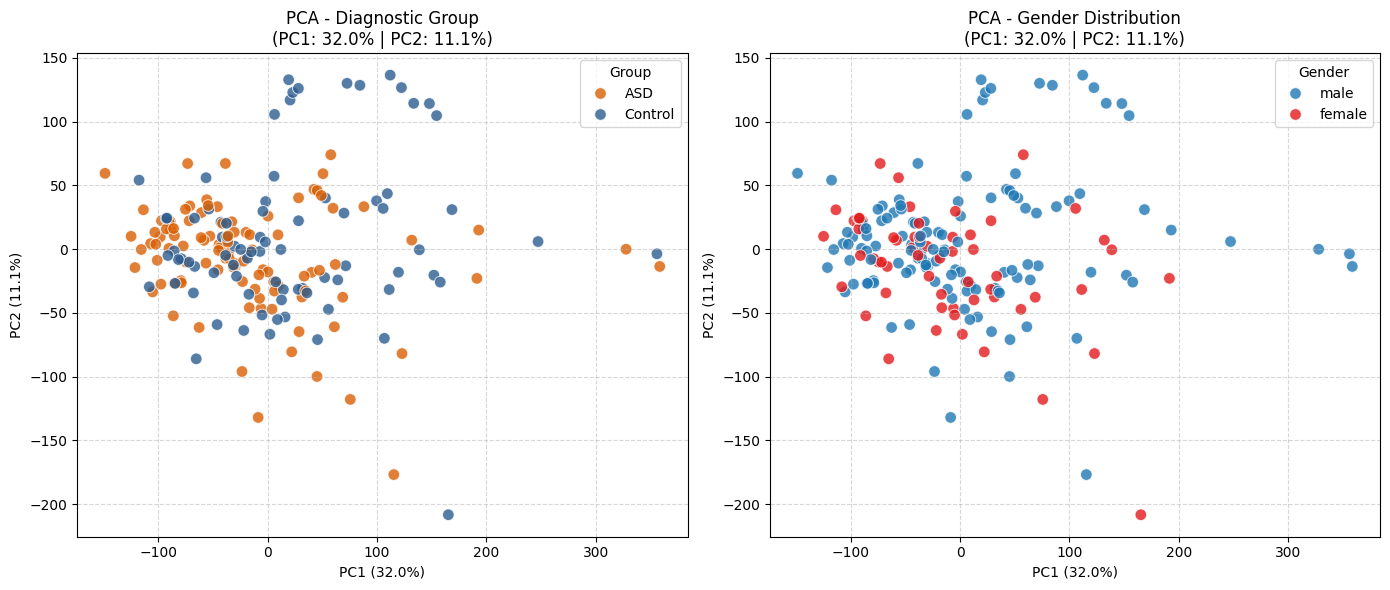


--- همبستگی آماری مؤلفه اول (PC1) با برچسب‌ها ---
همبستگی PC1 با بیماری (ASD): r = -0.221 (p-value = 2.4890e-03)
همبستگی PC1 با جنسیت (Male): r = 0.087 (p-value = 2.3565e-01)


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("در حال اجرای تحلیل PCA...")

# ۱. استانداردسازی ویژگی‌ها (میانگین 0 و انحراف معیار 1) برای اجرای صحیح PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ۲. اجرای PCA روی داده‌ها
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# درصد اطلاعات (واریانس) ذخیره‌شده در هر مؤلفه
var_ratio = pca.explained_variance_ratio_ * 100
print(f"واریانس توجیه‌شده توسط PC1: {var_ratio[0]:.2f}%")
print(f"واریانس توجیه‌شده توسط PC2: {var_ratio[1]:.2f}%")
print(f"مجموع واریانس ۲ مؤلفه اول: {var_ratio[0] + var_ratio[1]:.2f}%")

# ایجاد دیتافریم برای رسم نمودار
pca_df = pd.DataFrame(
    data=X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=X.index
)
pca_df["Group"] = metadata_indexed["group"].values
pca_df["Gender"] = metadata_indexed["gender"].values

# ۳. رسم نمودارها
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# نمودار ۱: تفکیک بر اساس گروه بیماری (ASD vs Control)
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Group",
    palette={"Control": "#2b5c8f", "ASD": "#d95f02"},
    alpha=0.8,
    s=70,
    ax=axes[0]
)
axes[0].set_title(f"PCA - Diagnostic Group\n(PC1: {var_ratio[0]:.1f}% | PC2: {var_ratio[1]:.1f}%)", fontsize=12)
axes[0].set_xlabel(f"PC1 ({var_ratio[0]:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_ratio[1]:.1f}%)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# نمودار ۲: تفکیک بر اساس جنسیت (Gender)
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="Gender",
    palette={"male": "#1f78b4", "female": "#e31a1c"},
    alpha=0.8,
    s=70,
    ax=axes[1]
)
axes[1].set_title(f"PCA - Gender Distribution\n(PC1: {var_ratio[0]:.1f}% | PC2: {var_ratio[1]:.1f}%)", fontsize=12)
axes[1].set_xlabel(f"PC1 ({var_ratio[0]:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_ratio[1]:.1f}%)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ۴. بررسی همبستگی مؤلفه‌های اول با متغیر جنسیت و گروه بیماری
from scipy.stats import pointbiserialr

gender_binary = (pca_df["Gender"] == "male").astype(int)
group_binary = (pca_df["Group"] == "ASD").astype(int)

corr_pc1_group, p_group = pointbiserialr(pca_df["PC1"], group_binary)
corr_pc1_gender, p_gender = pointbiserialr(pca_df["PC1"], gender_binary)

print("\n--- همبستگی آماری مؤلفه اول (PC1) با برچسب‌ها ---")
print(f"همبستگی PC1 با بیماری (ASD): r = {corr_pc1_group:.3f} (p-value = {p_group:.4e})")
print(f"همبستگی PC1 با جنسیت (Male): r = {corr_pc1_gender:.3f} (p-value = {p_gender:.4e})")

در حال اجرای تحلیل بیان افتراقی ژن‌ها (Differential Expression)...
تعداد ژن‌های با p-value خام کمتر از 0.05: 12084
تعداد ژن‌های با p-value خام کمتر از 0.01: 7878
تعداد ژن‌های معنادار با تصحیح FDR < 0.10: 12229

--- ۱۰ ژن برتر دارای بیشترین تغییر بیان ---
            log2FC    t_stat       p_value       FDR
Gene                                                
SCARNA17  0.454435  6.588374  4.584628e-10  0.000009
TIGD7     0.504758  6.494827  7.611578e-10  0.000009
RNU1-16P  0.377764  6.223180  3.237816e-09  0.000021
UBXN2A    0.227416  6.205598  3.551364e-09  0.000021
DTX4     -0.250873 -6.079712  6.851335e-09  0.000028
HMBS     -0.286090 -6.072221  7.122691e-09  0.000028
SNORD95   0.484831  6.036620  8.563209e-09  0.000028
SNORD21   0.678115  6.012222  9.711579e-09  0.000028
SNORD50A  0.745679  5.968022  1.218842e-08  0.000031
SNORA21   0.476580  5.944217  1.376877e-08  0.000031


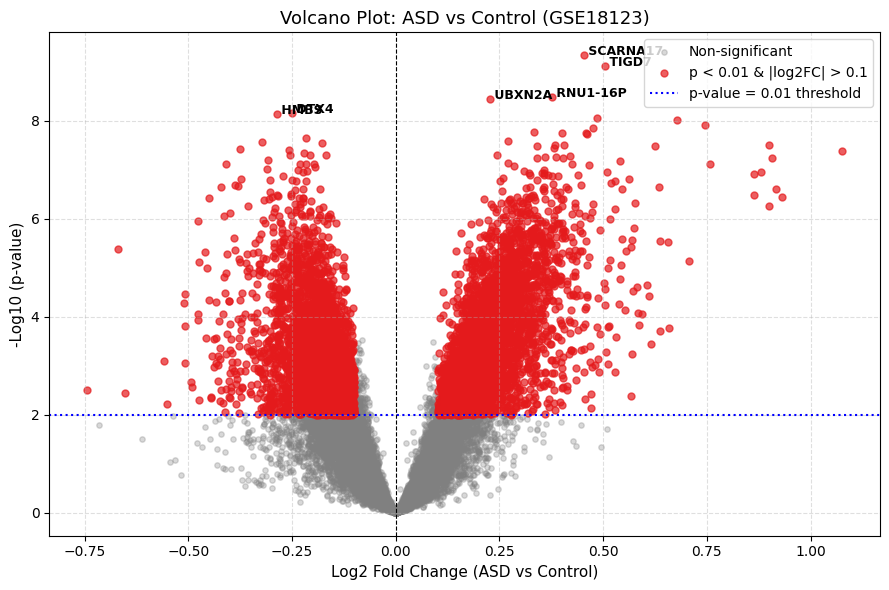

In [84]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

print("در حال اجرای تحلیل بیان افتراقی ژن‌ها (Differential Expression)...")

# ۱. آماده‌سازی متغیرهای طراحی آزمایش
# مدل خطی برای هر ژن: Gene_Expression ~ Group + Gender
# در اینجا اثر جنسیت کنترل می‌شود تا تفاوت حاصل، صرفاً مربوط به بیماری باشد
design_df = pd.DataFrame({
    "Intercept": 1.0,
    "ASD": (metadata_indexed["group"] == "ASD").astype(int),
    "Male": (metadata_indexed["gender"] == "male").astype(int)
}, index=metadata_indexed.index)

# ۲. برازش مدل رگرسیون خطی ساده برای تک‌تک ژن‌ها
results = []
X_genes = X.columns

for gene in X_genes:
    y_gene = X[gene].values
    model = sm.OLS(y_gene, design_df).fit()
    
    # ضریب اثر ASD (تفاوت میانگین در مقیاس log2)
    log2FC = model.params["ASD"]
    p_val = model.pvalues["ASD"]
    t_stat = model.tvalues["ASD"]
    
    results.append({
        "Gene": gene,
        "log2FC": log2FC,
        "t_stat": t_stat,
        "p_value": p_val
    })

de_table = pd.DataFrame(results).set_index("Gene")

# ۳. تصحیح خطای آزمون‌های چندگانه با روش FDR (Benjamini-Hochberg)
_, fdr_vals, _, _ = multipletests(de_table["p_value"], method="fdr_bh")
de_table["FDR"] = fdr_vals

# مرتب‌سازی بر اساس معنادارترین p-value
de_table = de_table.sort_values(by="p_value")

print(f"تعداد ژن‌های با p-value خام کمتر از 0.05: {(de_table['p_value'] < 0.05).sum()}")
print(f"تعداد ژن‌های با p-value خام کمتر از 0.01: {(de_table['p_value'] < 0.01).sum()}")
print(f"تعداد ژن‌های معنادار با تصحیح FDR < 0.10: {(de_table['FDR'] < 0.10).sum()}")

# نمایش ۱۰ ژن برتر
print("\n--- ۱۰ ژن برتر دارای بیشترین تغییر بیان ---")
print(de_table.head(10)[["log2FC", "t_stat", "p_value", "FDR"]])

# ۴. رسم نمودار آتشفشانی (Volcano Plot)
plt.figure(figsize=(9, 6))

# محاسبه منفی لگاریتم مبنای ۱۰ پی-ولیو
neg_log_p = -np.log10(de_table["p_value"] + 1e-300)

# تفکیک رنگی ژن‌های معنادار اولیه
is_sig = (de_table["p_value"] < 0.01) & (np.abs(de_table["log2FC"]) > 0.1)

plt.scatter(
    de_table.loc[~is_sig, "log2FC"], 
    neg_log_p[~is_sig], 
    c="grey", alpha=0.3, s=15, label="Non-significant"
)
plt.scatter(
    de_table.loc[is_sig, "log2FC"], 
    neg_log_p[is_sig], 
    c="#e41a1c", alpha=0.7, s=25, label="p < 0.01 & |log2FC| > 0.1"
)

# نام‌گذاری چند ژن برتر روی نمودار
top_genes = de_table.head(6)
for gene, row in top_genes.iterrows():
    plt.text(row["log2FC"], -np.log10(row["p_value"]), f" {gene}", fontsize=9, fontweight="bold")

plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.axhline(-np.log10(0.01), color="blue", linestyle=":", label="p-value = 0.01 threshold")

plt.title("Volcano Plot: ASD vs Control (GSE18123)", fontsize=13)
plt.xlabel("Log2 Fold Change (ASD vs Control)", fontsize=11)
plt.ylabel("-Log10 (p-value)", fontsize=11)
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

در حال اجرای پایپ‌لاین اعتبارسنجی بدون نشت اطلاعات (Repeated Stratified CV)...
  -> اجرای مدل: Logistic Regression (L2)


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarnin

  -> اجرای مدل: Logistic Regression (L1/Lasso)


c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\Asrefanavary\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

  -> اجرای مدل: Support Vector Machine (Linear)
  -> اجرای مدل: Random Forest

--- جدول نتایج ارزیابی مدل‌ها روی ۲۵ فولد آزمون دست‌نخورده ---
                                ROC-AUC (Mean ± SD) Balanced Acc (Mean ± SD)  \
Model                                                                          
Logistic Regression (L2)              0.737 ± 0.069            0.665 ± 0.068   
Logistic Regression (L1/Lasso)        0.723 ± 0.070            0.648 ± 0.081   
Support Vector Machine (Linear)       0.722 ± 0.065            0.639 ± 0.059   
Random Forest                         0.706 ± 0.075            0.644 ± 0.064   

                                Sensitivity (Mean ± SD)  \
Model                                                     
Logistic Regression (L2)                  0.739 ± 0.122   
Logistic Regression (L1/Lasso)            0.718 ± 0.142   
Support Vector Machine (Linear)           0.780 ± 0.092   
Random Forest                             0.734 ± 0.116   

                      

C:\Users\Asrefanavary\AppData\Local\Temp\ipykernel_16196\1681662197.py:86: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(auc_data, labels=model_labels, patch_artist=True,


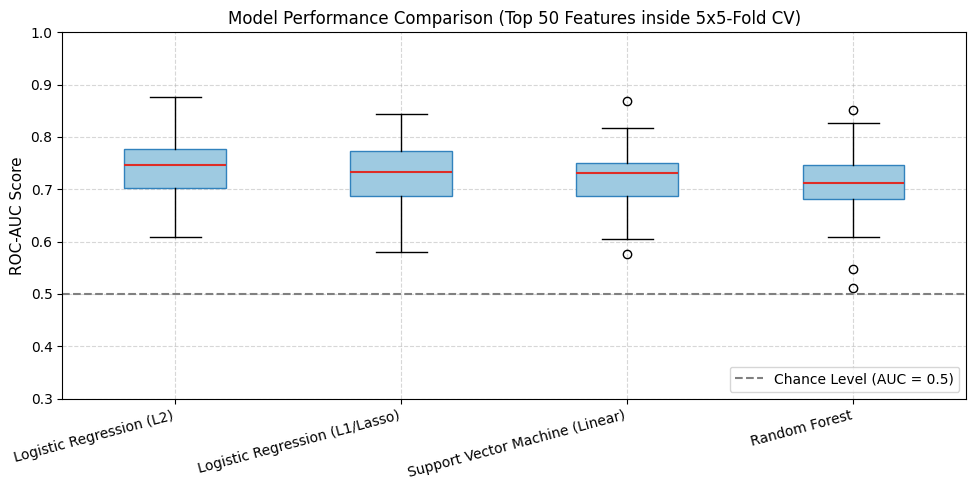

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, recall_score, confusion_matrix

print("در حال اجرای پایپ‌لاین اعتبارسنجی بدون نشت اطلاعات (Repeated Stratified CV)...")

# ۱. تعریف پایپ‌لاین‌ها با تعداد ویژگی منتخب (مثلاً ۵۰ ژن برتر در هر فولد)
K_FEATURES = 50

models = {
    "Logistic Regression (L2)": LogisticRegression(penalty="l2", C=0.1, solver="liblinear", random_state=42),
    "Logistic Regression (L1/Lasso)": LogisticRegression(penalty="l1", C=0.5, solver="liblinear", random_state=42),
    "Support Vector Machine (Linear)": SVC(kernel="linear", C=0.01, probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
}

# ۲. ساختار اعتبارسنجی: ۵ فولد لایه‌بندی‌شده با ۵ بار تکرار (مجموعاً ۲۵ بار آزمایش)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

results_list = []

for model_name, clf in models.items():
    print(f"  -> اجرای مدل: {model_name}")
    
    # ساخت پایپ‌لاین: اول مقیاس‌بندی، سپس انتخاب ویژگی، سپس یادگیری مدل
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=K_FEATURES)),
        ("classifier", clf)
    ])
    
    fold_aucs = []
    fold_baccs = []
    fold_sens = []
    fold_spec = []
    
    for train_idx, test_idx in rskf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # برازش مدل فقط روی داده‌های آموزش
        pipe.fit(X_train, y_train)
        
        # پیش‌بینی احتمال و کلاس برای داده‌های تست دست‌نخورده
        y_pred = pipe.predict(X_test)
        if hasattr(pipe.named_steps["classifier"], "predict_proba"):
            y_prob = pipe.predict_proba(X_test)[:, 1]
        else:
            y_prob = pipe.decision_function(X_test)
            
        # محاسبه ماتریس درهم‌ریختگی و شاخص‌ها
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        fold_aucs.append(roc_auc_score(y_test, y_prob))
        fold_baccs.append(balanced_accuracy_score(y_test, y_pred))
        fold_sens.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fold_spec.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        
    results_list.append({
        "Model": model_name,
        "ROC-AUC (Mean ± SD)": f"{np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}",
        "Balanced Acc (Mean ± SD)": f"{np.mean(fold_baccs):.3f} ± {np.std(fold_baccs):.3f}",
        "Sensitivity (Mean ± SD)": f"{np.mean(fold_sens):.3f} ± {np.std(fold_sens):.3f}",
        "Specificity (Mean ± SD)": f"{np.mean(fold_spec):.3f} ± {np.std(fold_spec):.3f}",
        "raw_aucs": fold_aucs
    })

results_df = pd.DataFrame(results_list).set_index("Model")

print("\n--- جدول نتایج ارزیابی مدل‌ها روی ۲۵ فولد آزمون دست‌نخورده ---")
print(results_df[["ROC-AUC (Mean ± SD)", "Balanced Acc (Mean ± SD)", "Sensitivity (Mean ± SD)", "Specificity (Mean ± SD)"]])

# ۳. رسم نمودار جعبه‌ای (Boxplot) توزیع ROC-AUC در طول فولدها
plt.figure(figsize=(10, 5))
auc_data = [res["raw_aucs"] for res in results_list]
model_labels = [res["Model"] for res in results_list]

plt.boxplot(auc_data, labels=model_labels, patch_artist=True,
            boxprops=dict(facecolor="#9ecae1", color="#3182bd"),
            medianprops=dict(color="#de2d26", linewidth=1.5))
plt.axhline(0.5, color="grey", linestyle="--", label="Chance Level (AUC = 0.5)")
plt.ylabel("ROC-AUC Score", fontsize=11)
plt.title(f"Model Performance Comparison (Top {K_FEATURES} Features inside 5x5-Fold CV)", fontsize=12)
plt.xticks(rotation=15, ha="right")
plt.ylim(0.3, 1.0)
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

در حال محاسبه پایداری ژن‌های منتخب در طول ۲۵ فولد...
تعداد کل ژن‌های منحصربه‌فردی که حداقل یک‌بار انتخاب شدند: 270
تعداد ژن‌های پایدار مرکزی (حضور در حداقل ۸۰٪ فولدها): 9
تعداد ژن‌های ۱۰۰٪ پایدار (حضور در تمام ۲۵ فولد): 3

--- ۲۰ ژن دارای بیشترین پایداری در مدل‌سازی ---
    Gene  Selection_Count  Selection_Frequency (%)
RNU1-16P               25                    100.0
SCARNA17               25                    100.0
   TIGD7               25                    100.0
CCDC144A               23                     92.0
  UBXN2A               21                     84.0
FLJ41327               20                     80.0
 PRPF38B               20                     80.0
  RBM12B               20                     80.0
 SNORA21               20                     80.0
   SPG20               19                     76.0
    HMBS               19                     76.0
    ESF1               17                     68.0
   RBM39               17                     68.0
  SACM1L       

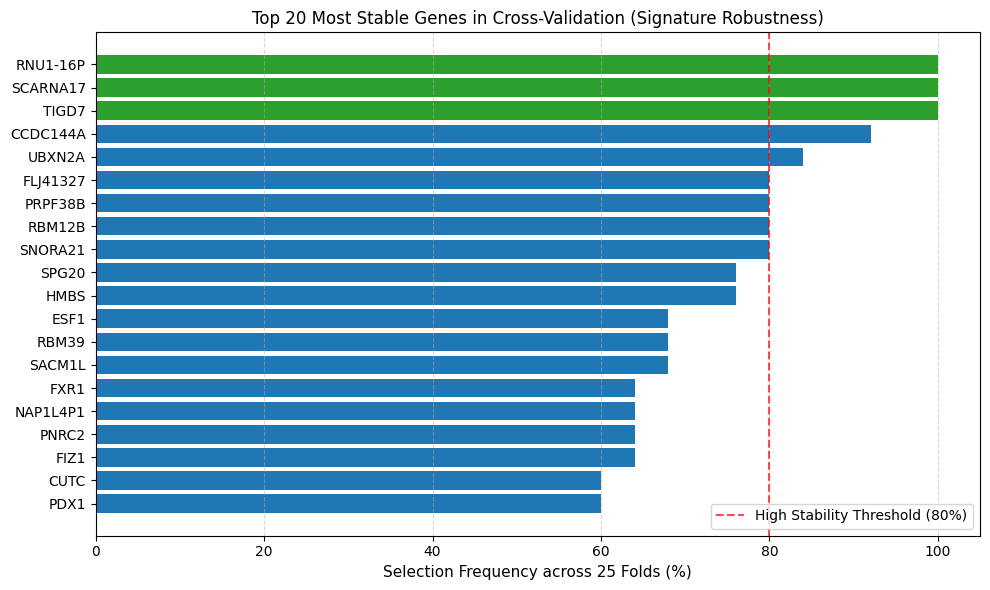

In [86]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RepeatedStratifiedKFold

print("در حال محاسبه پایداری ژن‌های منتخب در طول ۲۵ فولد...")

K_FEATURES = 50
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

selected_genes_all_folds = []

# جمع‌آوری ۵۰ ژن برتر انتخاب‌شده در هر یک از ۲۵ فولد
for train_idx, _ in rskf.split(X, y):
  X_train = X.iloc[train_idx]
  y_train = y[train_idx]

  selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
  selector.fit(X_train, y_train)

  # نام ژن‌های انتخاب‌شده در این فولد
  chosen_genes = X.columns[selector.get_support()].tolist()
  selected_genes_all_folds.extend(chosen_genes)

# محاسبه فراوانی انتخاب هر ژن
gene_counts = Counter(selected_genes_all_folds)
stability_df = pd.DataFrame(
    gene_counts.most_common(), columns=["Gene", "Selection_Count"]
)
stability_df["Selection_Frequency (%)"] = (
    stability_df["Selection_Count"] / 25
) * 100

# ژن‌های کاملاً پایدار (انتخاب‌شده در حداقل ۸۰٪ فولدها)
stable_core_genes = stability_df[stability_df["Selection_Frequency (%)"] >= 80]

print(
    f"تعداد کل ژن‌های منحصربه‌فردی که حداقل یک‌بار انتخاب شدند: {len(stability_df)}"
)
print(
    "تعداد ژن‌های پایدار مرکزی (حضور در حداقل ۸۰٪ فولدها):"
    f" {len(stable_core_genes)}"
)
print(
    "تعداد ژن‌های ۱۰۰٪ پایدار (حضور در تمام ۲۵ فولد):"
    f" {(stability_df['Selection_Frequency (%)'] == 100).sum()}"
)

print("\n--- ۲۰ ژن دارای بیشترین پایداری در مدل‌سازی ---")
print(stability_df.head(20).to_string(index=False))

# رسم نمودار پایداری ۲۰ ژن برتر
plt.figure(figsize=(10, 6))
top_20 = stability_df.head(20)

colors = [
    "#2ca02c" if freq == 100 else "#1f77b4"
    for freq in top_20["Selection_Frequency (%)"]
]
plt.barh(top_20["Gene"][::-1], top_20["Selection_Frequency (%)"][::-1], color=colors[::-1])
plt.xlabel("Selection Frequency across 25 Folds (%)", fontsize=11)
plt.title(
    "Top 20 Most Stable Genes in Cross-Validation (Signature Robustness)",
    fontsize=12,
)
plt.axvline(
    80,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="High Stability Threshold (80%)",
)
plt.xlim(0, 105)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

در حال اجرای تحلیل غنی‌سازی مسیرهای زیستی (Enrichment Analysis)...
تعداد ژن‌های ورودی به تحلیل مسیرهای زیستی: 99
فهرست ژن‌های منتخب نمونه: ['SCARNA17', 'TIGD7', 'RNU1-16P', 'UBXN2A', 'DTX4', 'HMBS', 'SNORD95', 'SNORD21', 'SNORD50A', 'SNORA21']

--- تعداد مسیرهای زیستی معنادار شناسایی‌شده: 91 ---
           Gene_set                                               Term  \
61    Reactome_2022                  mRNA 3-End Processing R-HSA-72187   
62    Reactome_2022  RNA Polymerase II Transcription Termination R-...   
60    Reactome_2022  Processing Of Capped Intron-Containing Pre-mRN...   
63    Reactome_2022  ZBP1(DAI) Mediated Induction Of Type I IFNs R-...   
64    Reactome_2022  Transport Of Mature mRNA Derived From An Intro...   
2   KEGG_2021_Human                   Herpes simplex virus 1 infection   
3   KEGG_2021_Human                                      RNA transport   
0   KEGG_2021_Human                                        Spliceosome   
1   KEGG_2021_Human               Mat

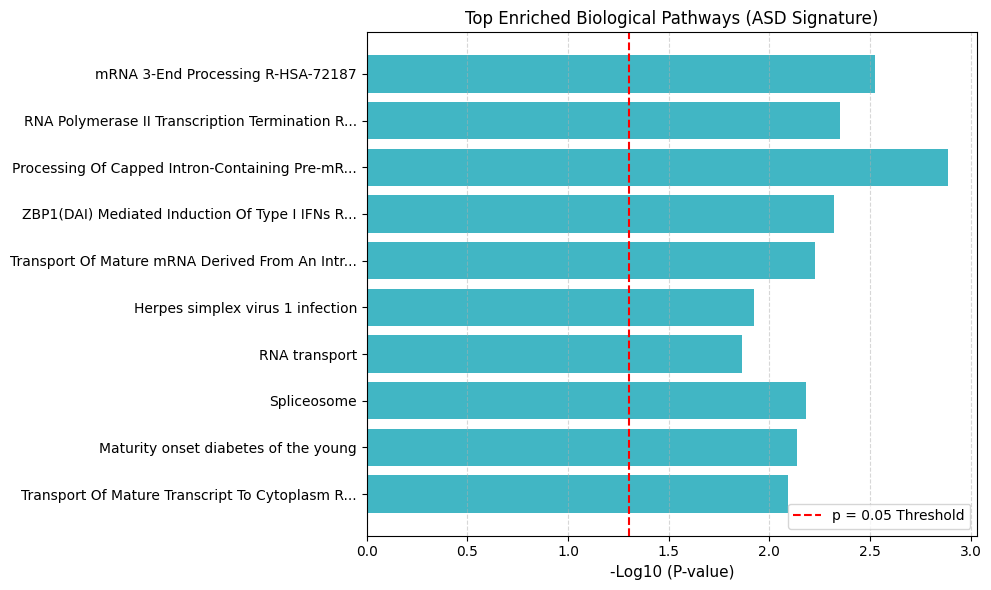

In [87]:
import gseapy as gp
import matplotlib.pyplot as plt
import pandas as pd

print("در حال اجرای تحلیل غنی‌سازی مسیرهای زیستی (Enrichment Analysis)...")

# ۱. استخراج ژن‌های کاندید برای تحلیل عملکردی
# ترکیبی از ژن‌های دارای پایداری بالا (حضور در حداقل ۵۰٪ فولدها)
candidate_genes = stability_df[stability_df["Selection_Frequency (%)"] >= 50][
    "Gene"
].tolist()

# اگر تعداد ژن‌ها کمتر از ۳۰ باشد، از ژن‌های برتر معنادار تحلیل افتراقی (مرحله ۳) استفاده می‌کنیم
if len(candidate_genes) < 30:
  candidate_genes = de_table.head(100).index.tolist()

# حذف شناسه‌های فاقد پروتئین استاندارد یا نام‌های نامعتبر
clean_gene_list = [
    g for g in candidate_genes if not g.startswith("FLJ") and "///" not in g
]

print(f"تعداد ژن‌های ورودی به تحلیل مسیرهای زیستی: {len(clean_gene_list)}")
print(f"فهرست ژن‌های منتخب نمونه: {clean_gene_list[:10]}")

# ۲. اجرای آزمون غنی‌سازی با دیتابیس‌های معتبر جهانی (KEGG و Reactome و Biological Process)
gene_sets = [
    "KEGG_2021_Human",
    "Reactome_2022",
    "GO_Biological_Process_2023",
]

try:
  enr_results = gp.enrichr(
      gene_list=clean_gene_list,
      gene_sets=gene_sets,
      organism="human",
      outdir=None,  # بدون ذخیره اجباری روی دیسک
  )

  res_df = enr_results.results

  # فیلتر نتایج معنادار بر اساس p-value
  sig_pathways = res_df[res_df["P-value"] < 0.05].sort_values(
      by="Adjusted P-value"
  )

  print(
      "\n--- تعداد مسیرهای زیستی معنادار شناسایی‌شده:"
      f" {len(sig_pathways)} ---"
  )
  print(
      sig_pathways[
          ["Gene_set", "Term", "Overlap", "P-value", "Adjusted P-value"]
      ].head(10)
  )

  # ۳. رسم نمودار حبابی/میله‌ای ۱۰ مسیر برتر معنادار
  plt.figure(figsize=(10, 6))
  top_terms = sig_pathways.head(10)

  # خلاصه کردن اسامی خیلی طولانی مسیرها برای نمایش تمیز در نمودار
  short_terms = [
      t.split(" (")[0][:45] + "..." if len(t.split(" (")[0]) > 45 else t
      for t in top_terms["Term"]
  ]

  plt.barh(short_terms[::-1], -np.log10(top_terms["P-value"][::-1]), color="#41b6c4")
  plt.xlabel("-Log10 (P-value)", fontsize=11)
  plt.title(
      "Top Enriched Biological Pathways (ASD Signature)",
      fontsize=12,
  )
  plt.axvline(
      -np.log10(0.05),
      color="red",
      linestyle="--",
      label="p = 0.05 Threshold",
  )
  plt.grid(axis="x", linestyle="--", alpha=0.5)
  plt.legend(loc="lower right")
  plt.tight_layout()
  plt.show()

except Exception as e:
  print(f"خطا در اتصال به وب‌سرویس Enrichr: {e}")
  print(
      "در صورت اختلال شبکه، می‌توان فایل ژن‌ها را به‌صورت آفلاین تحلیل کرد."
  )